In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    "../data/processed/aufschreibung_hra_clean.csv",
    sep=","
)

print("Data loaded successfully")


Data loaded successfully


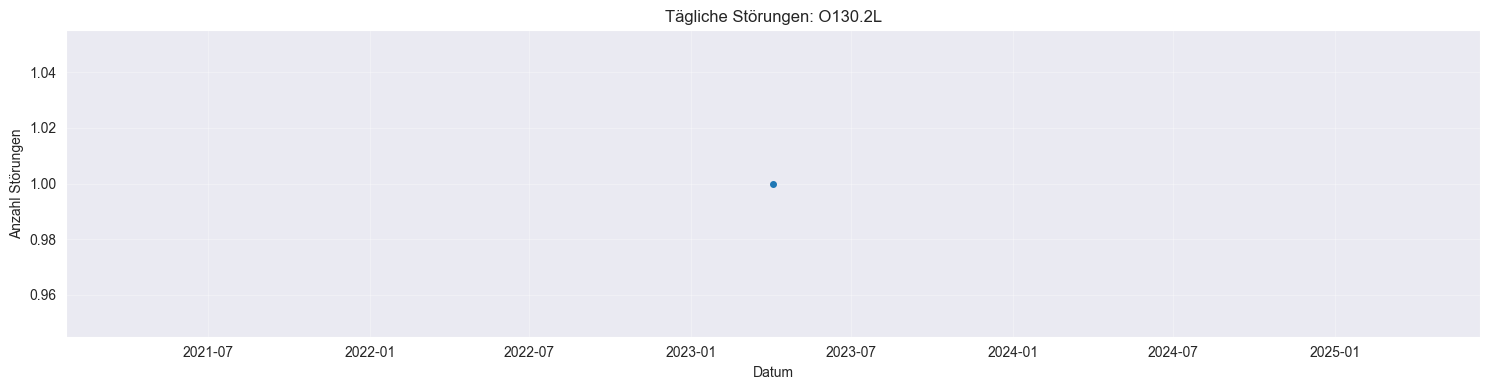

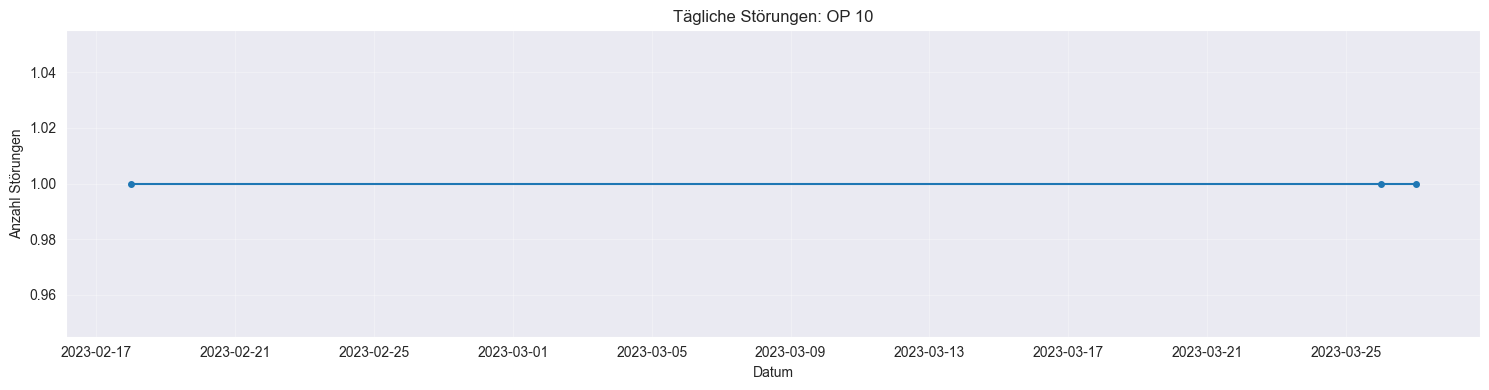

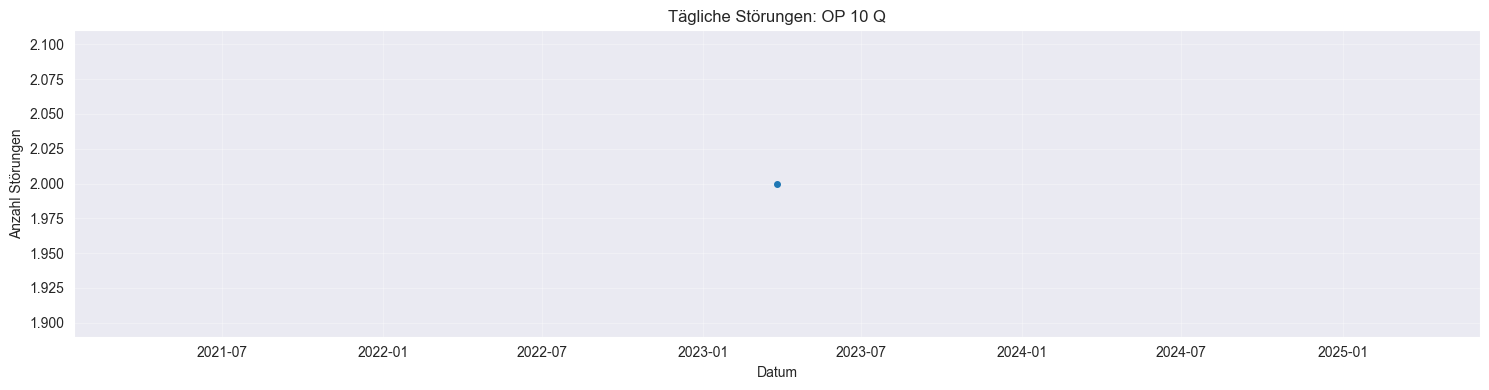

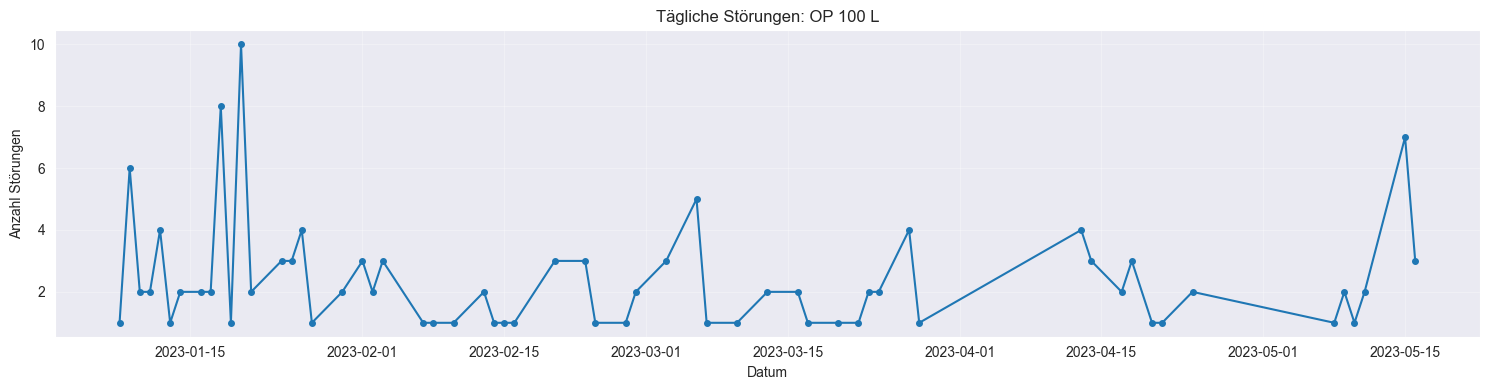

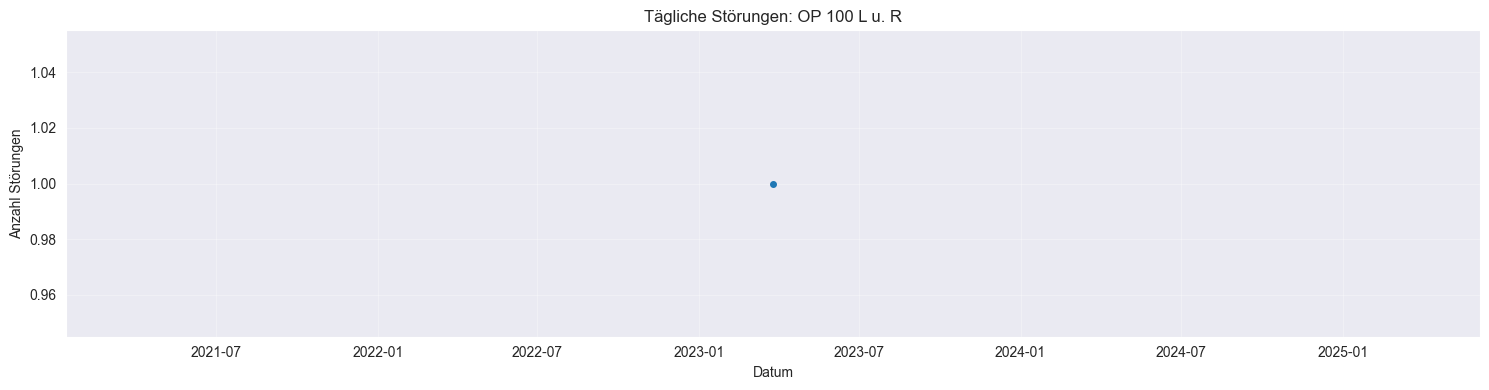

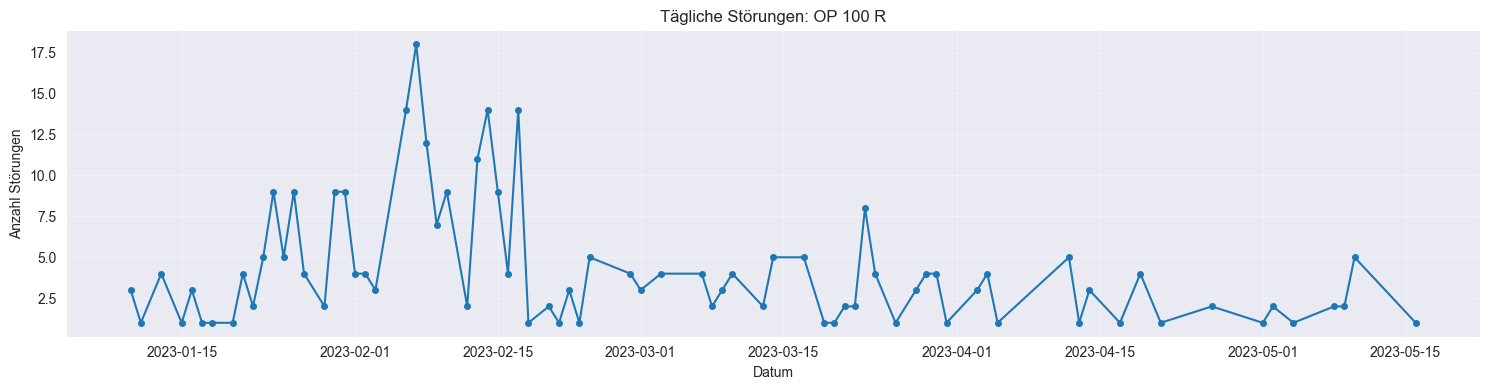

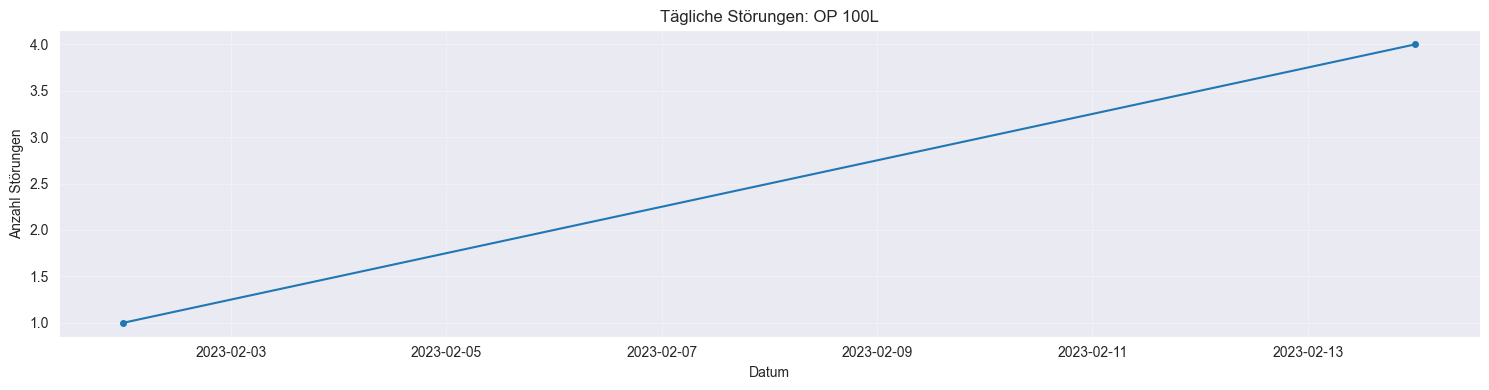

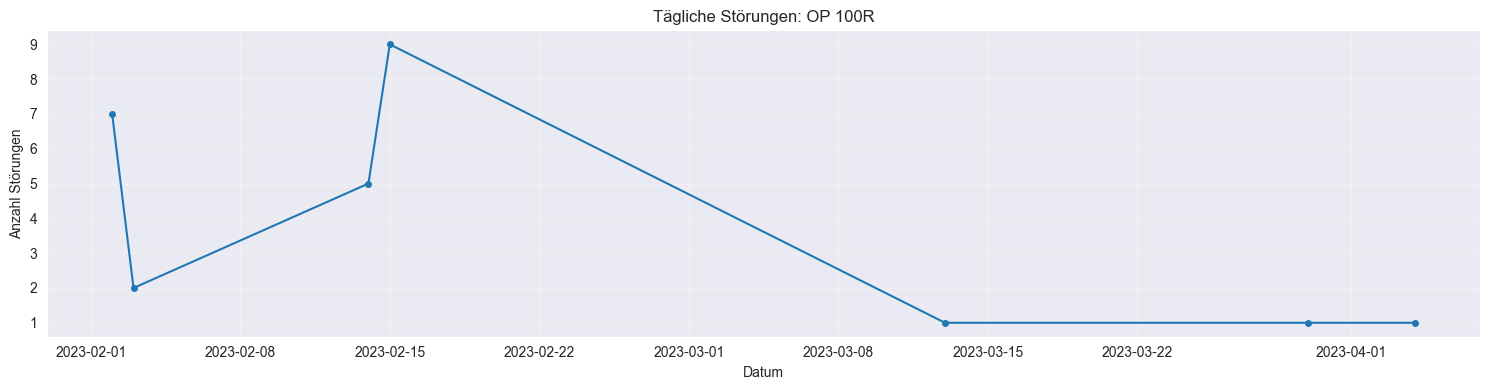

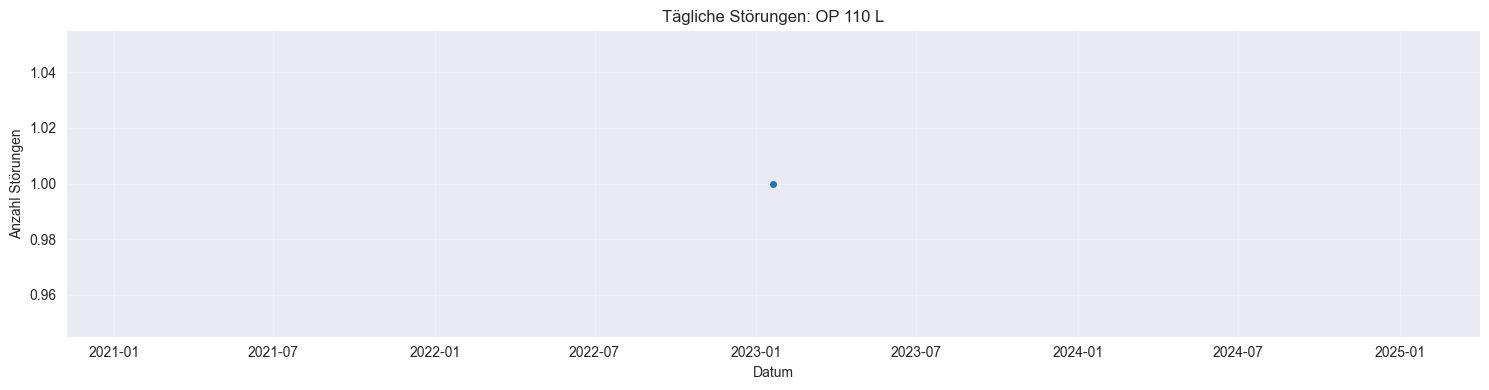

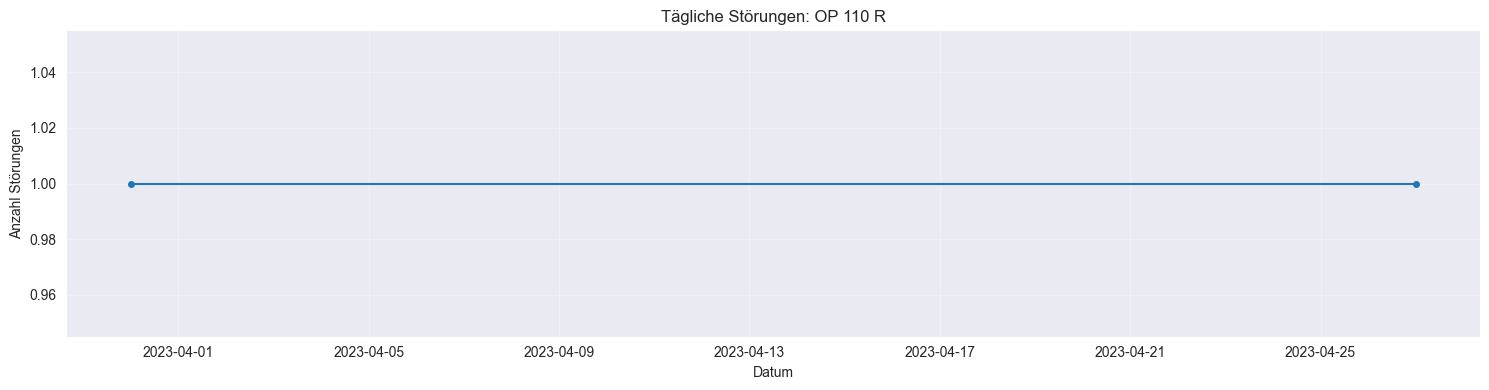

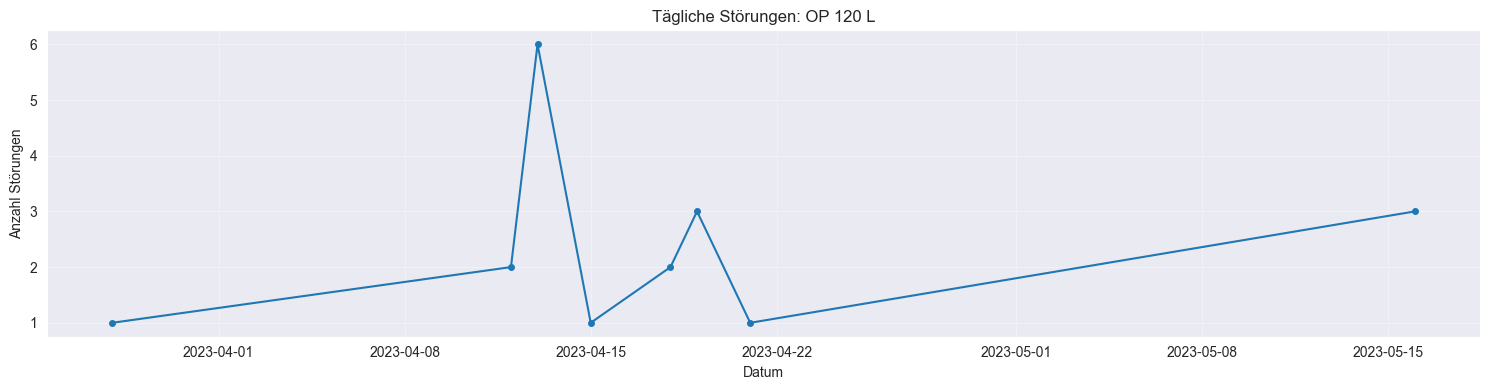

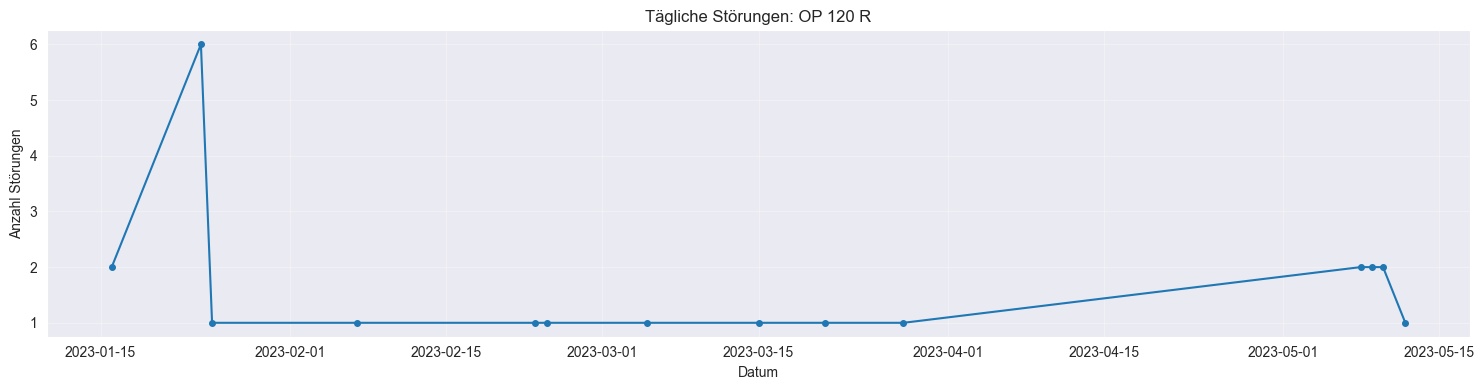

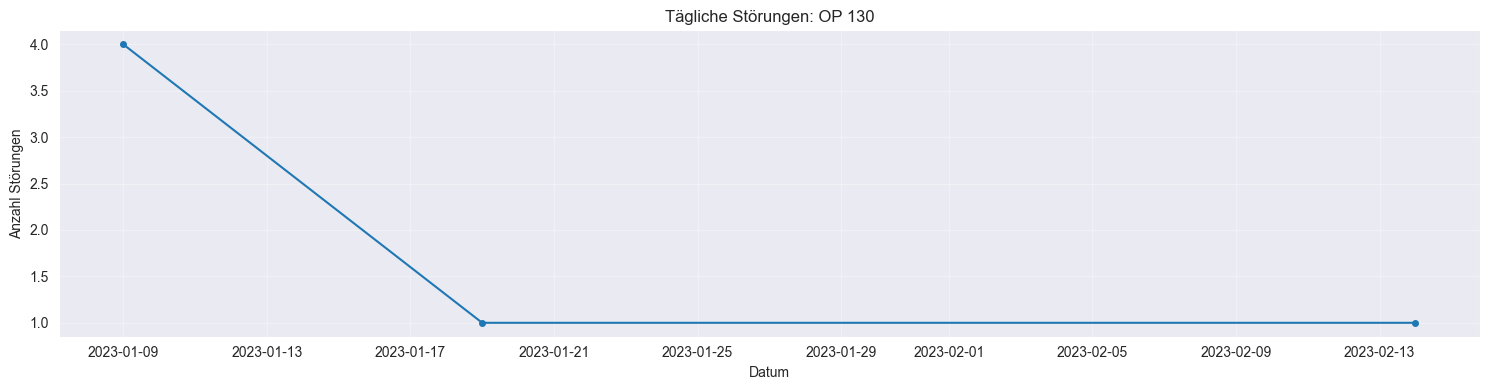

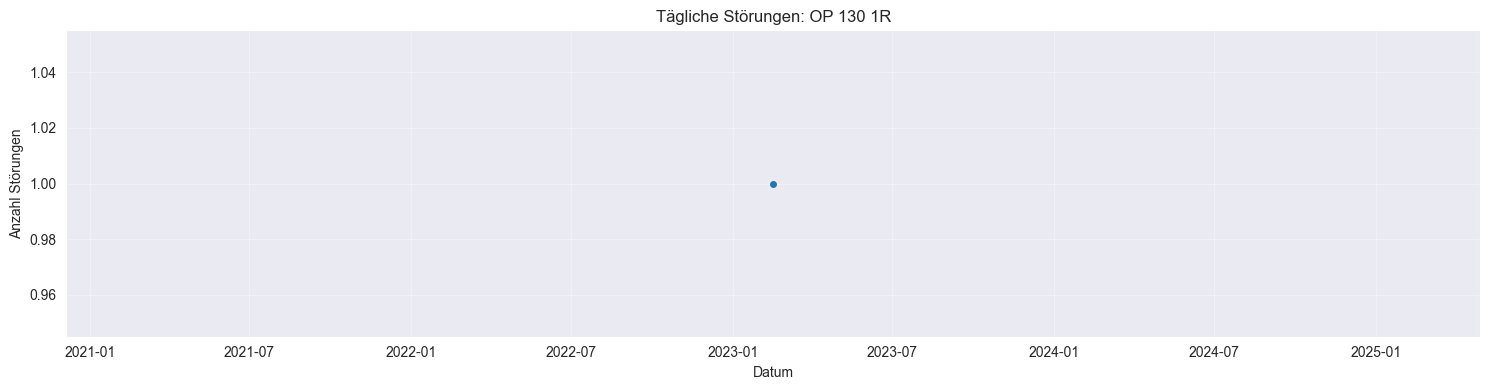

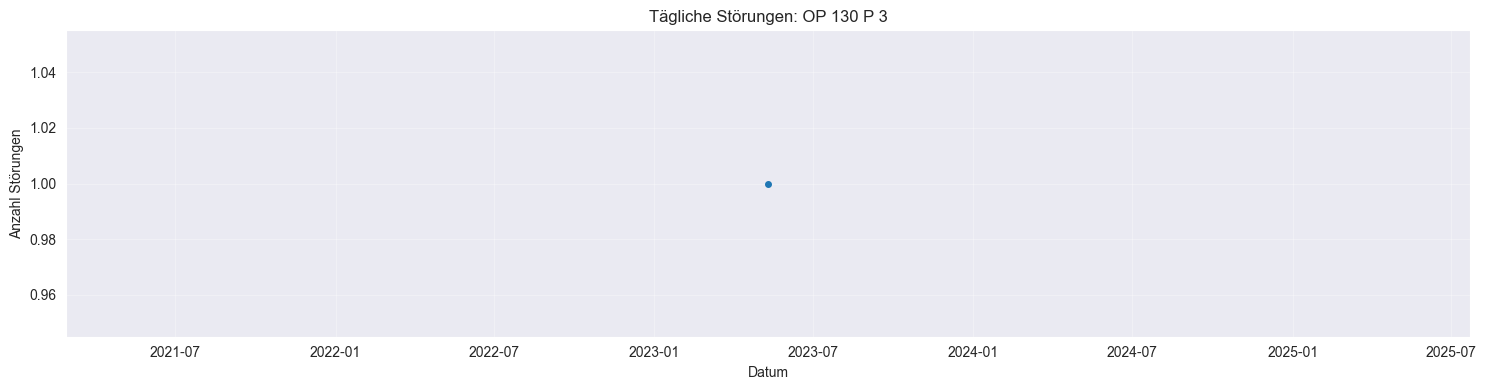

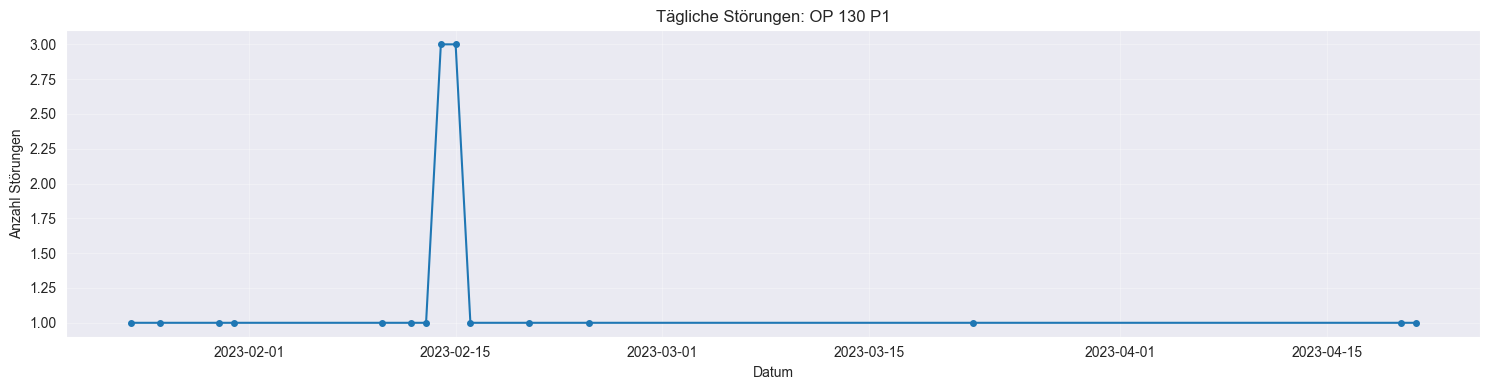

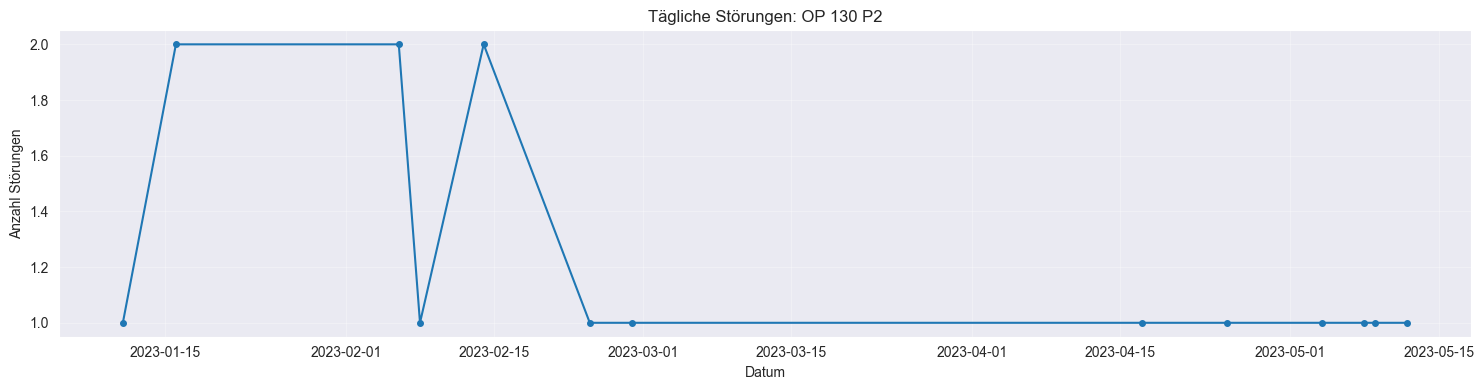

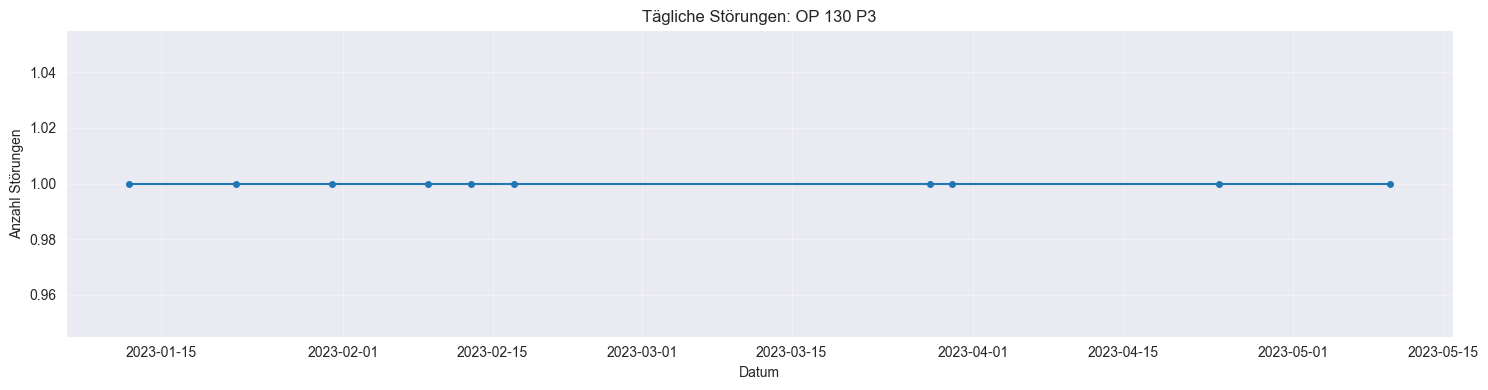

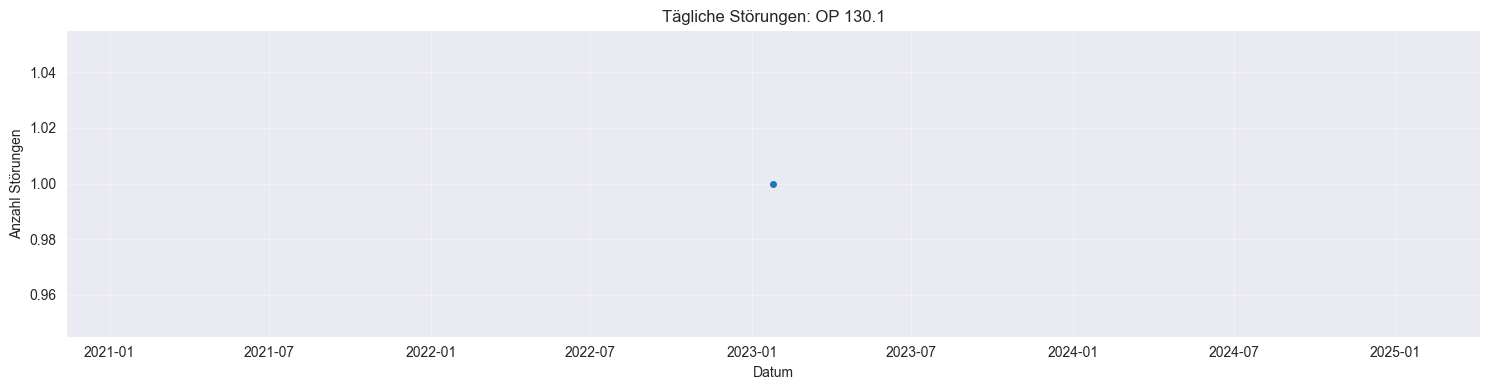

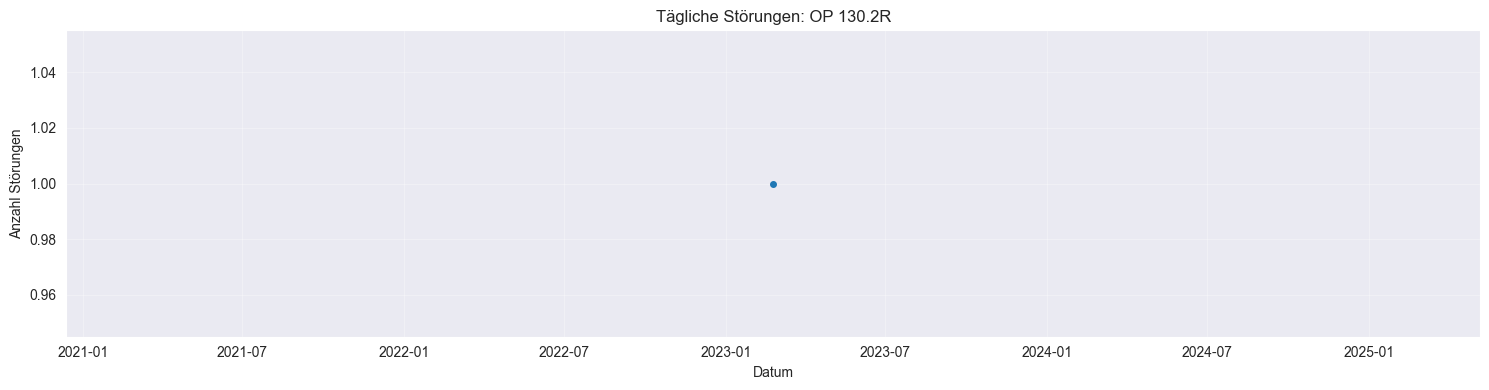

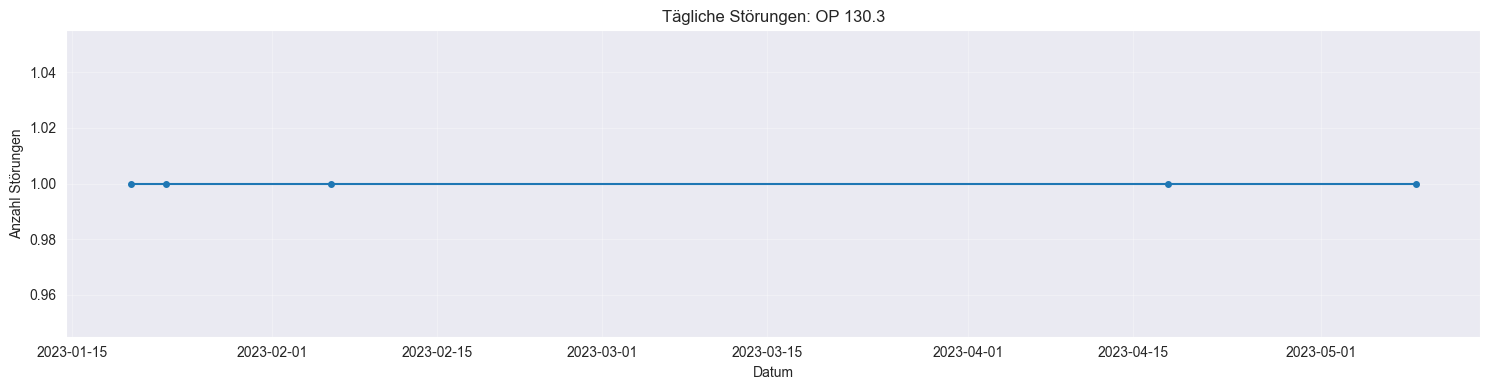

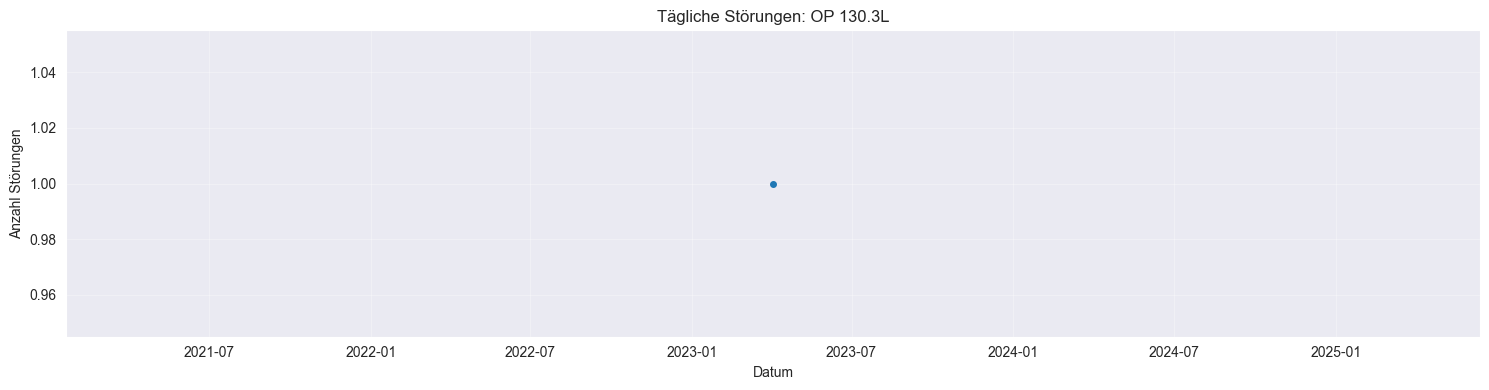

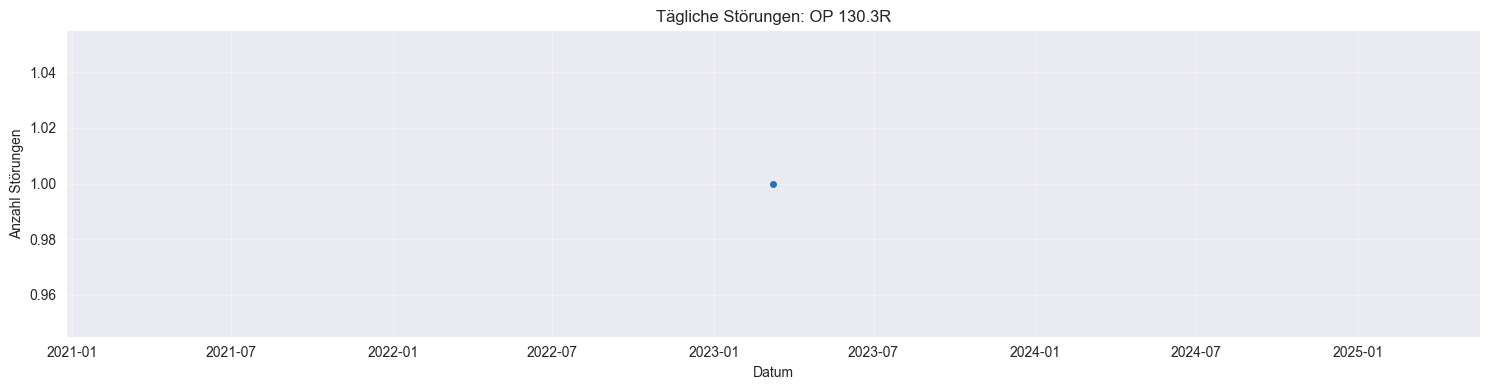

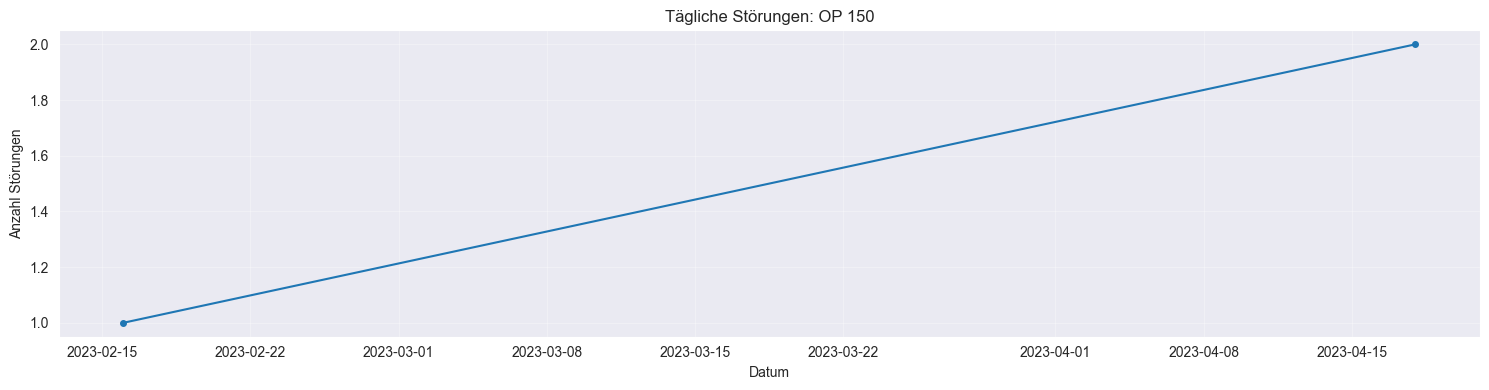

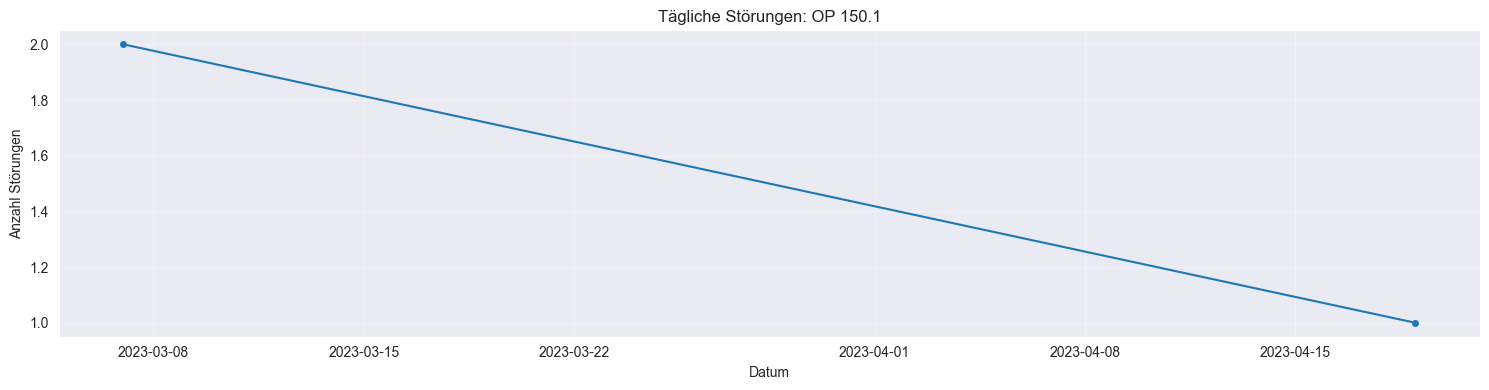

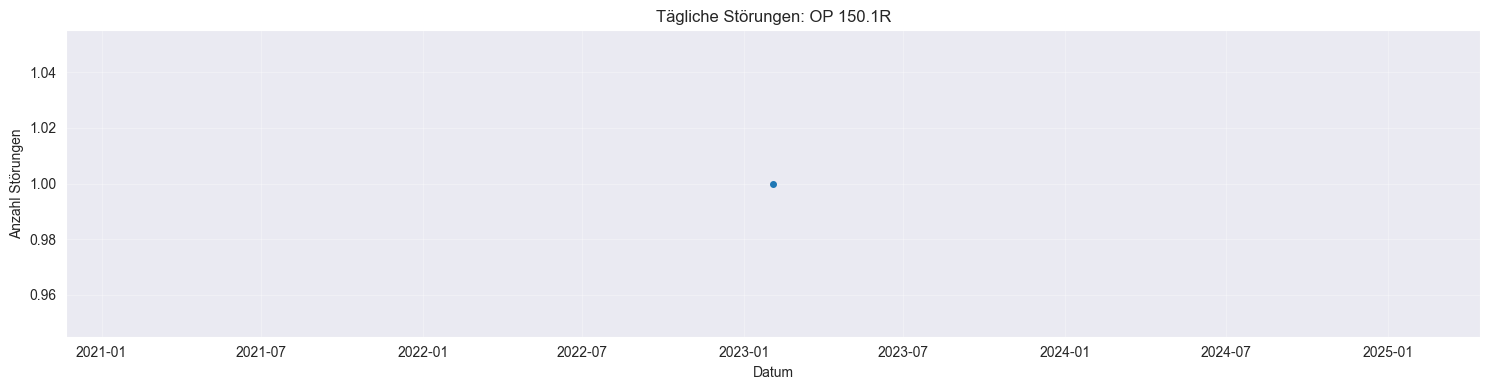

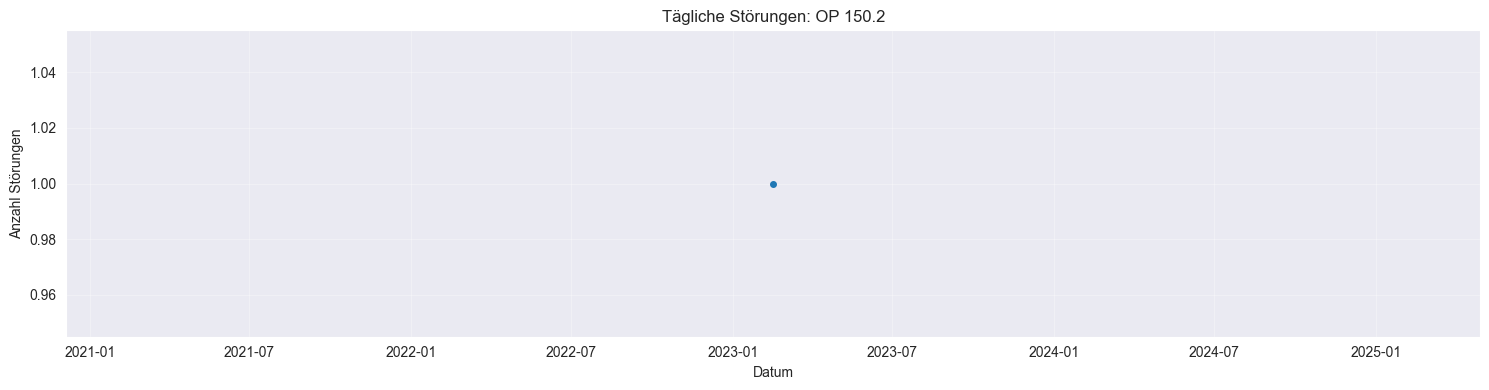

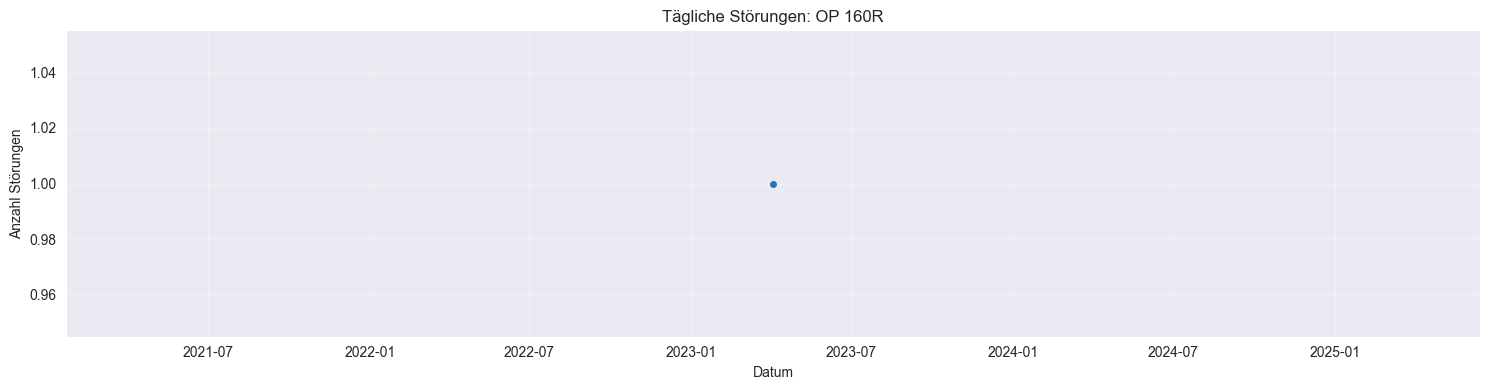

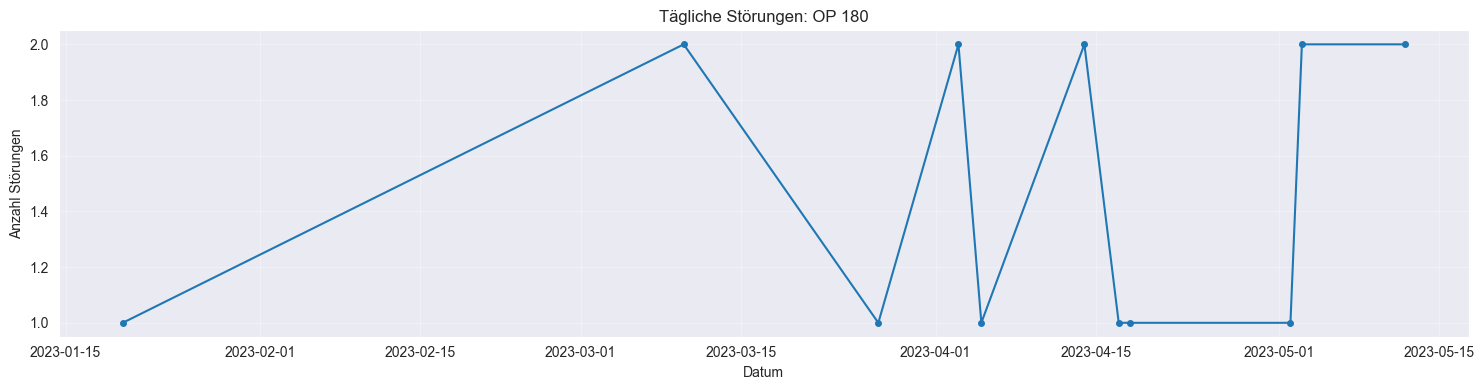

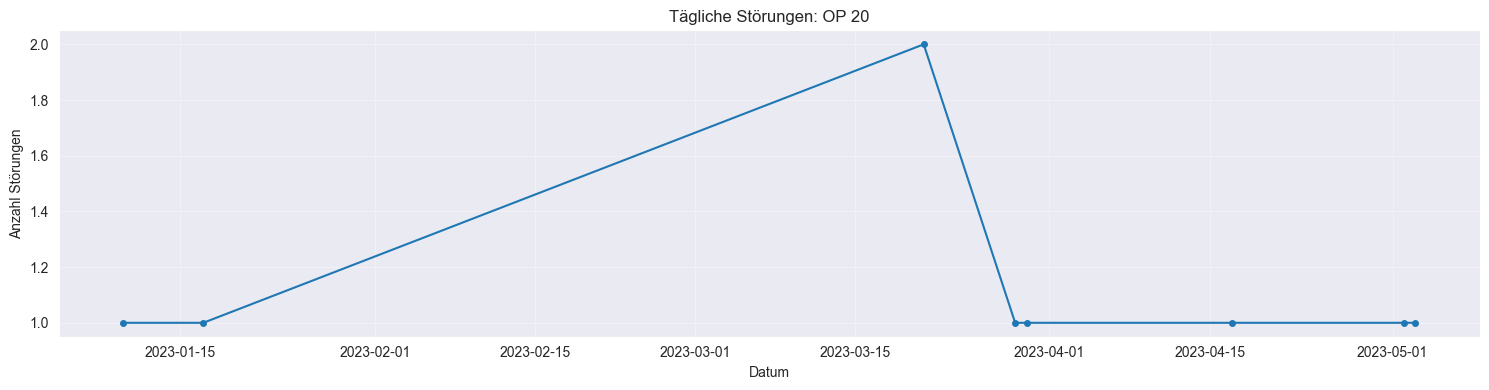

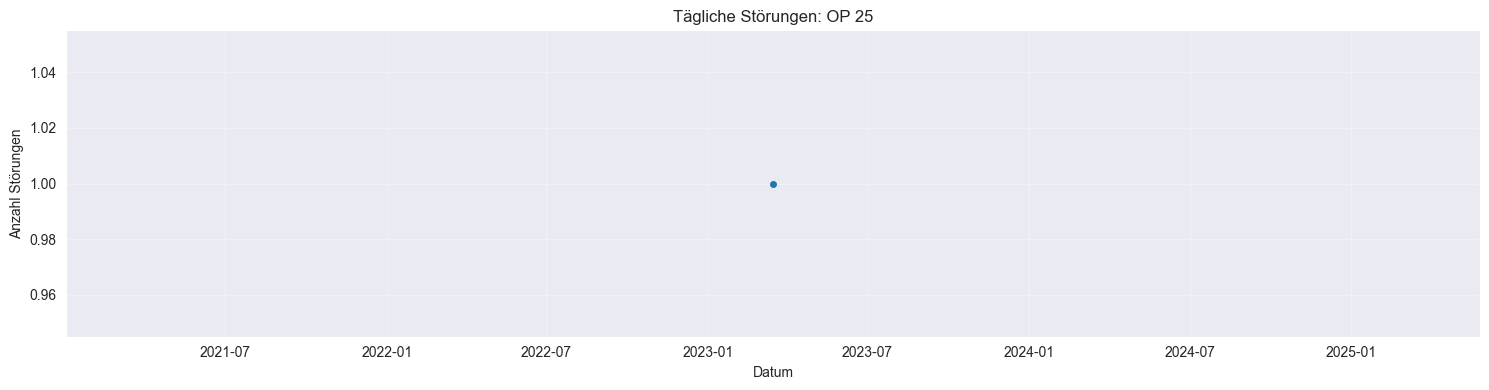

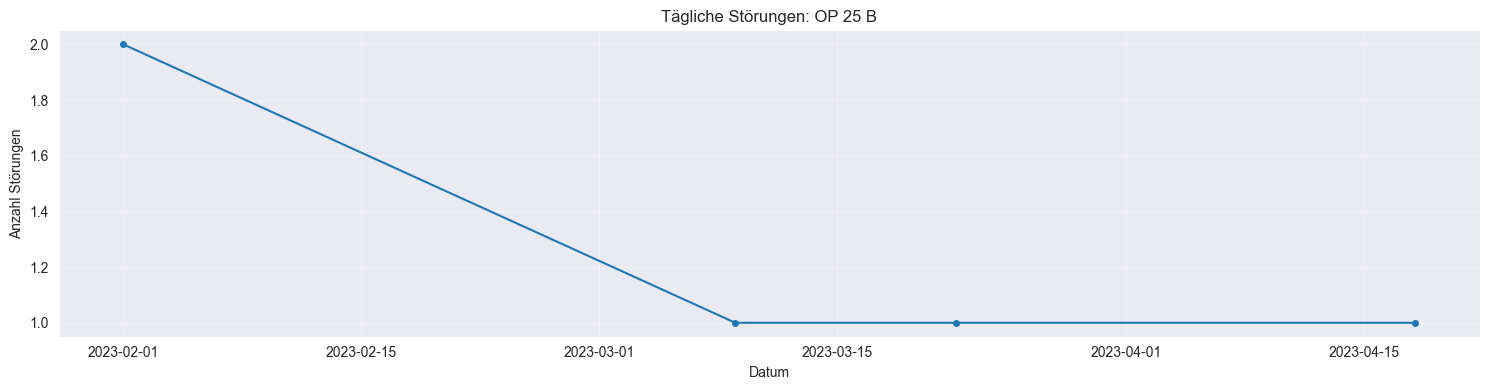

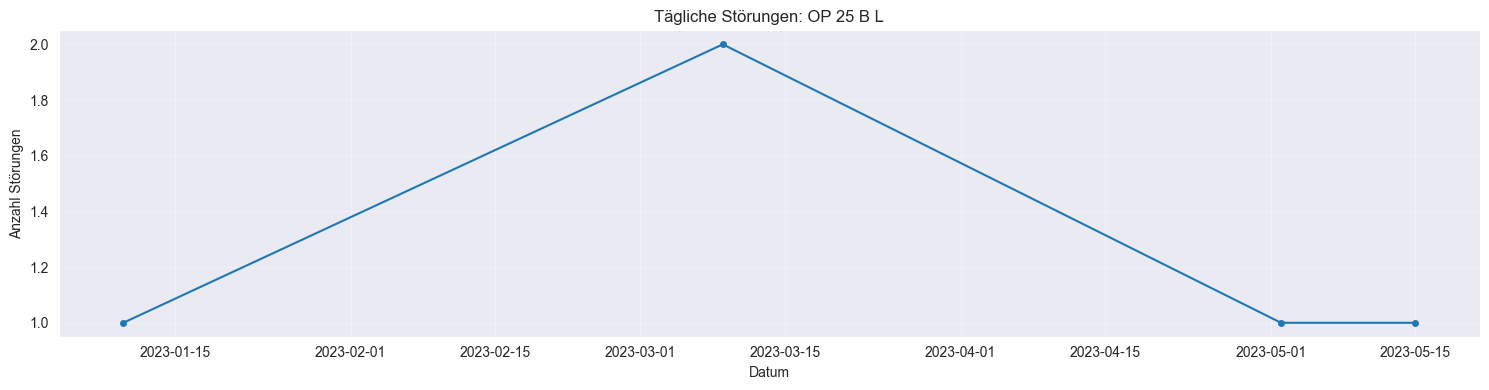

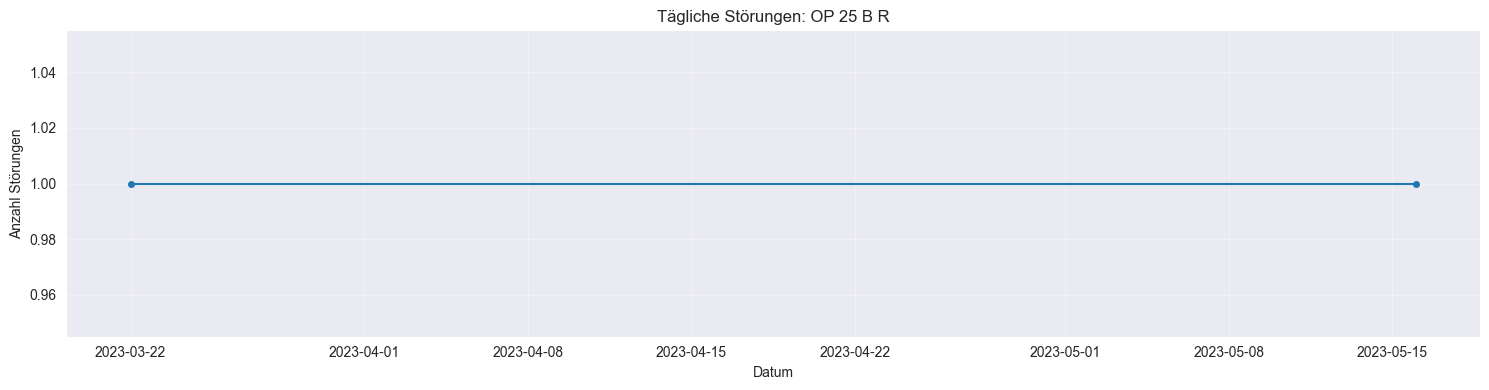

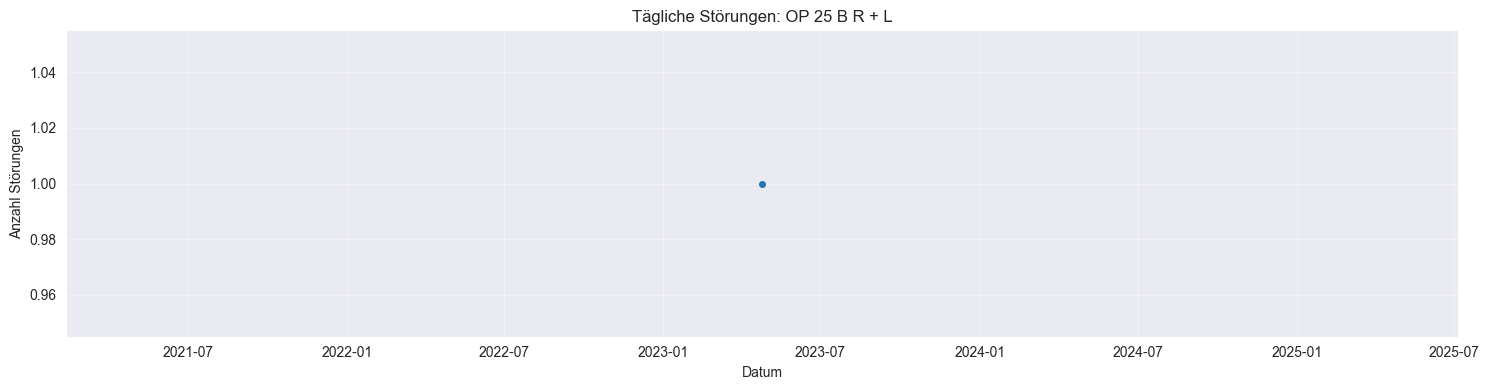

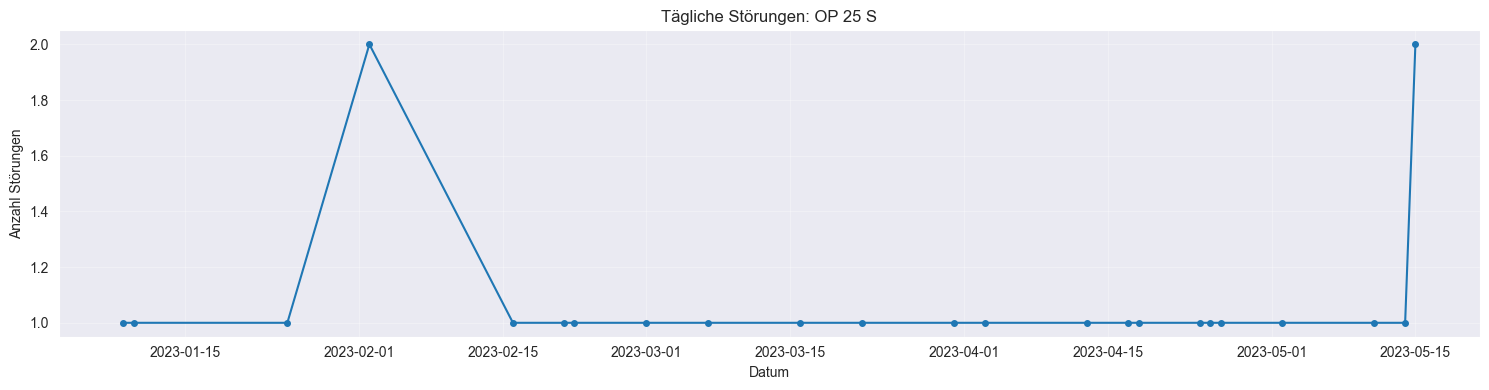

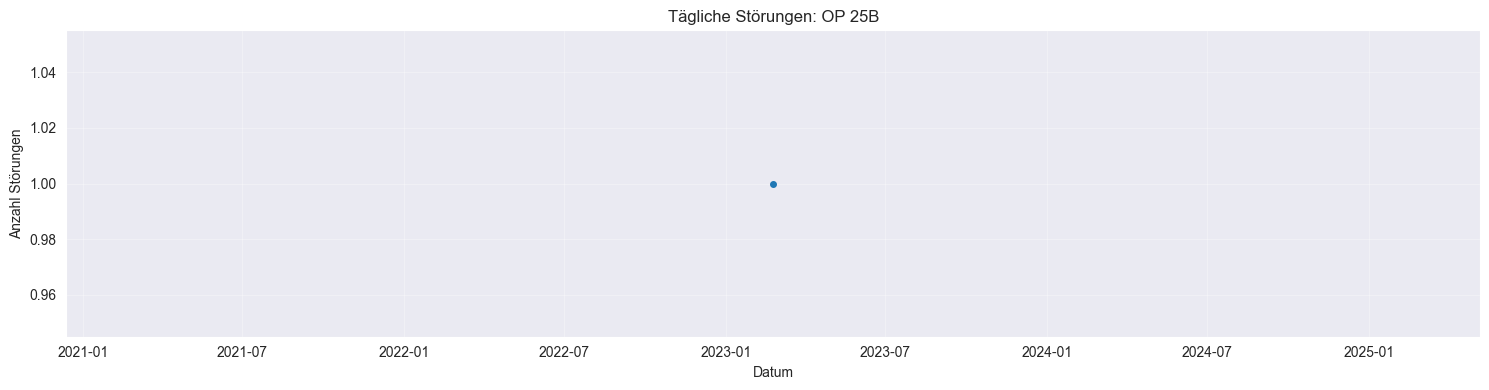

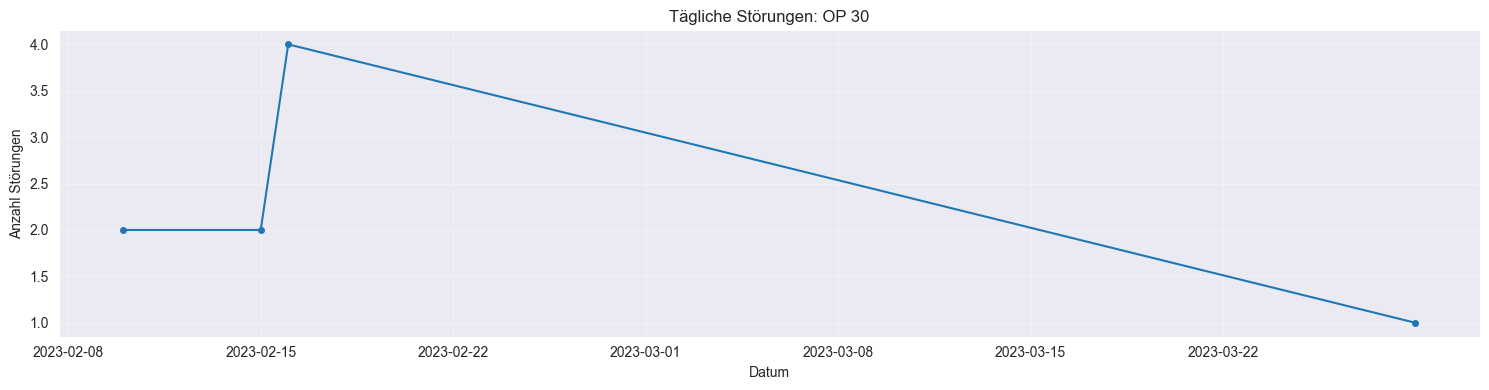

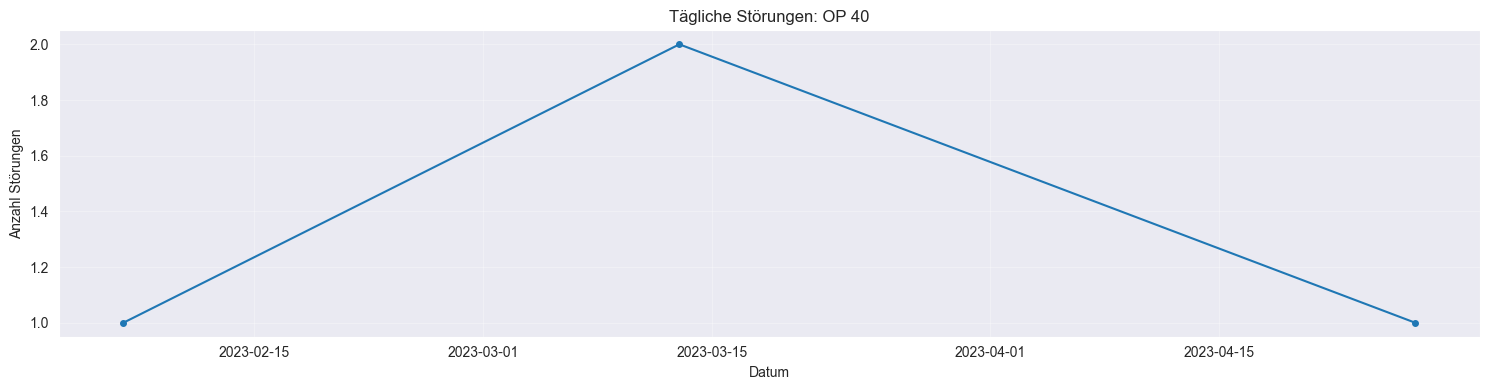

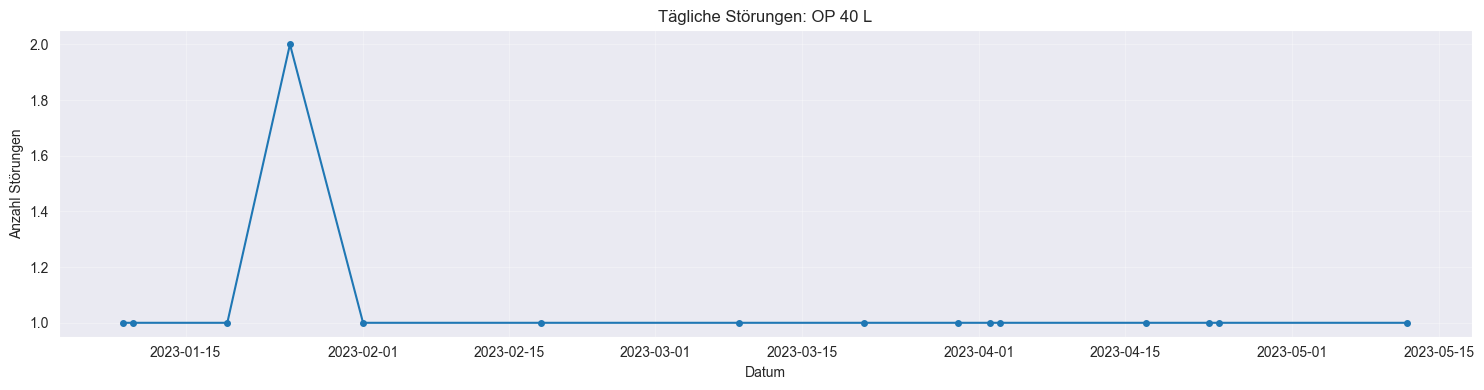

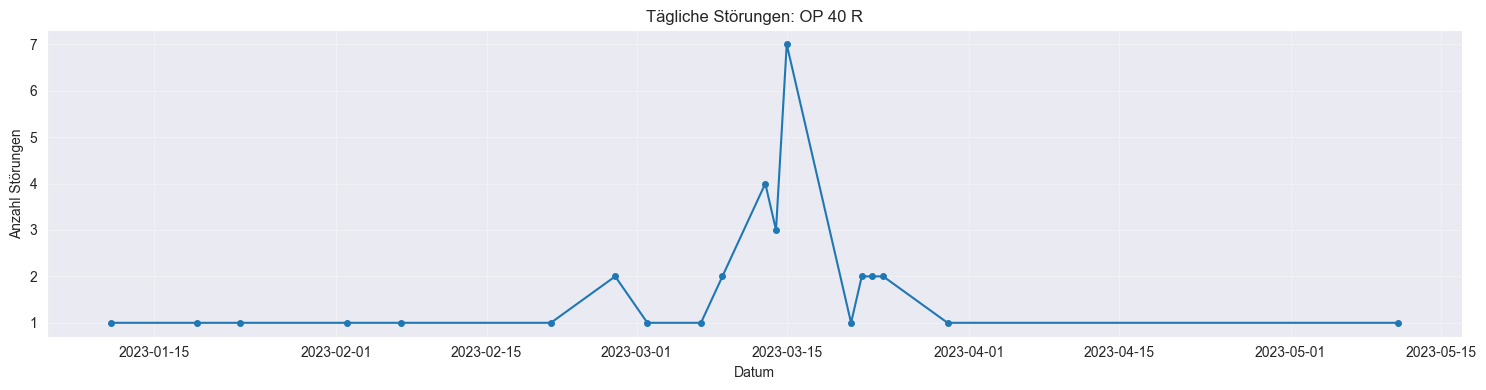

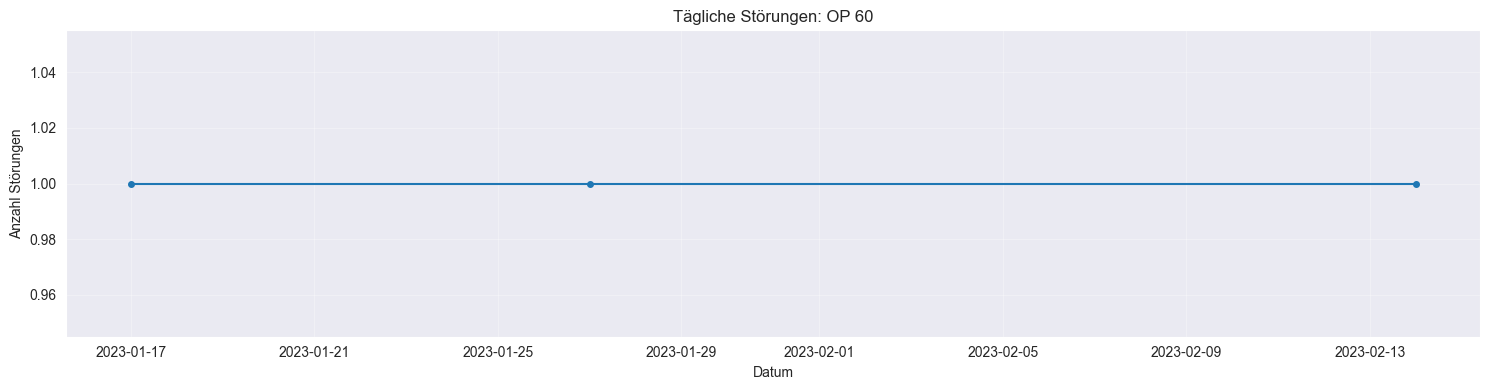

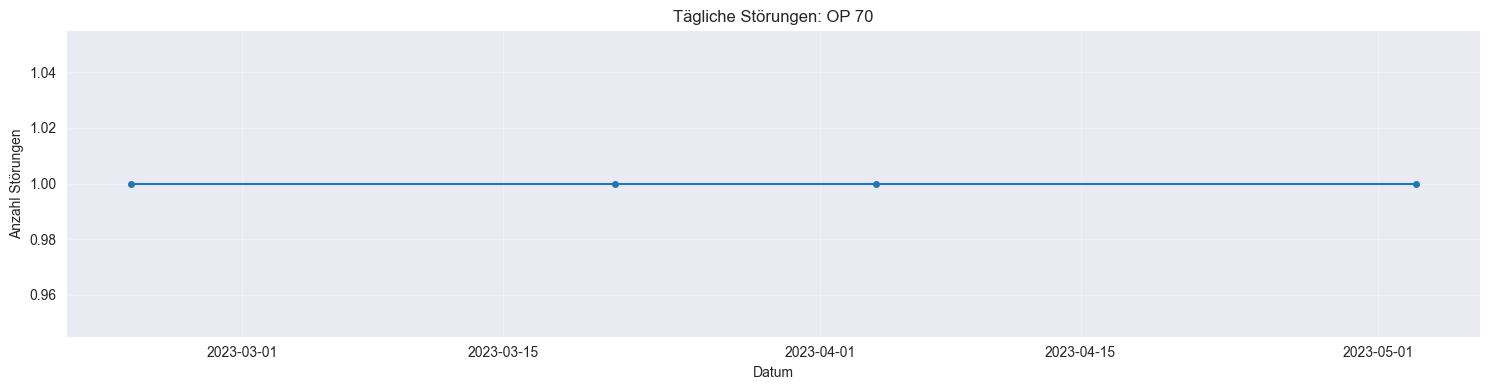

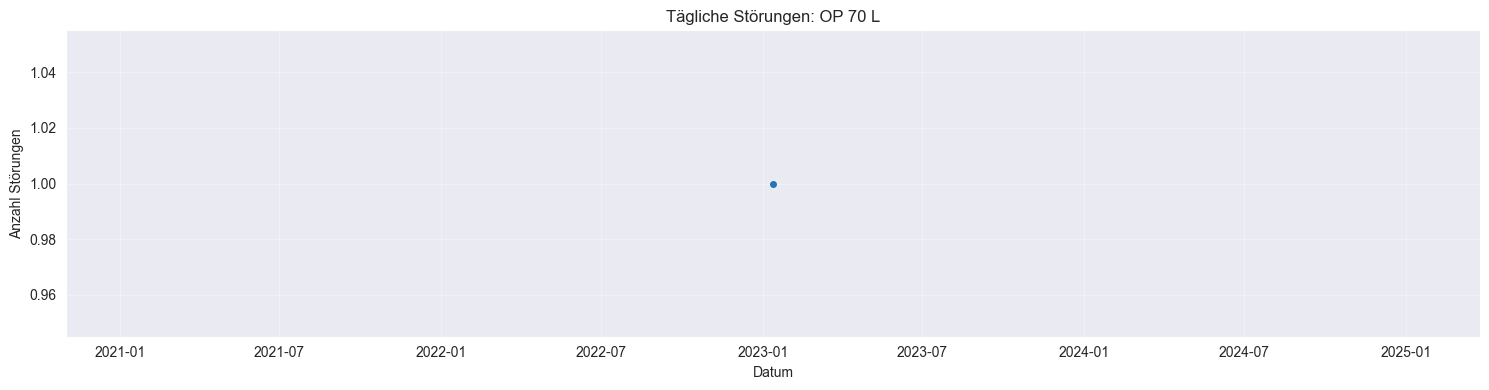

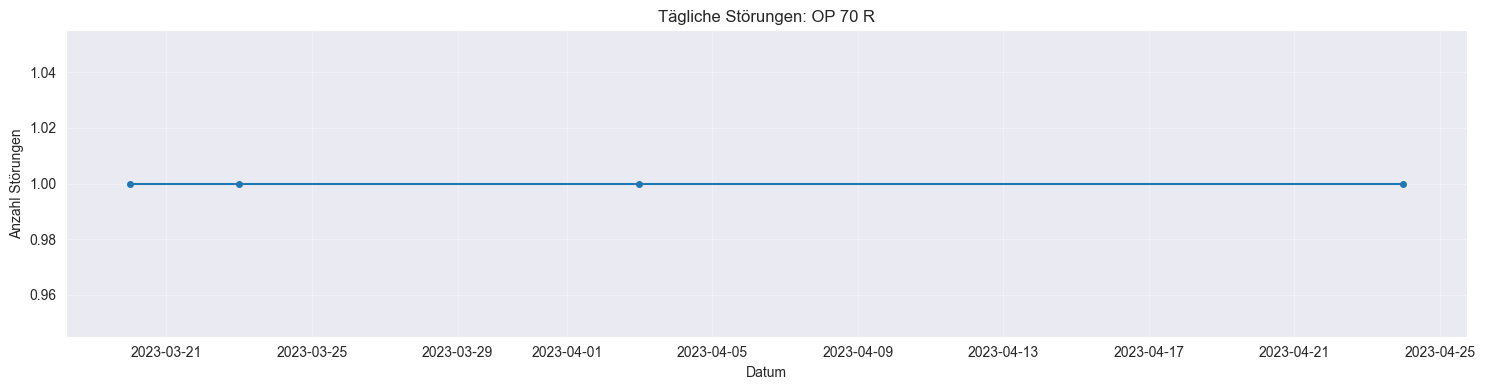

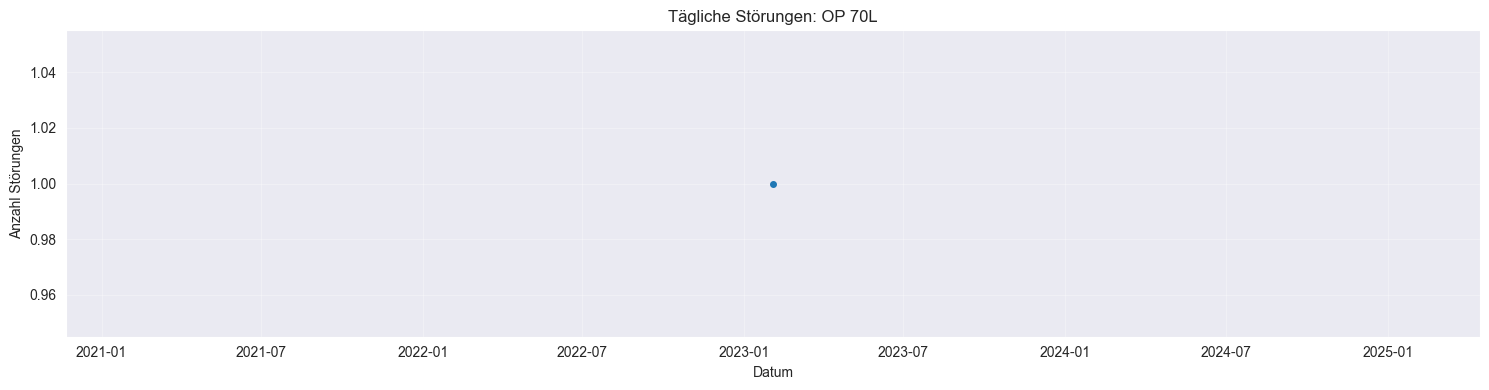

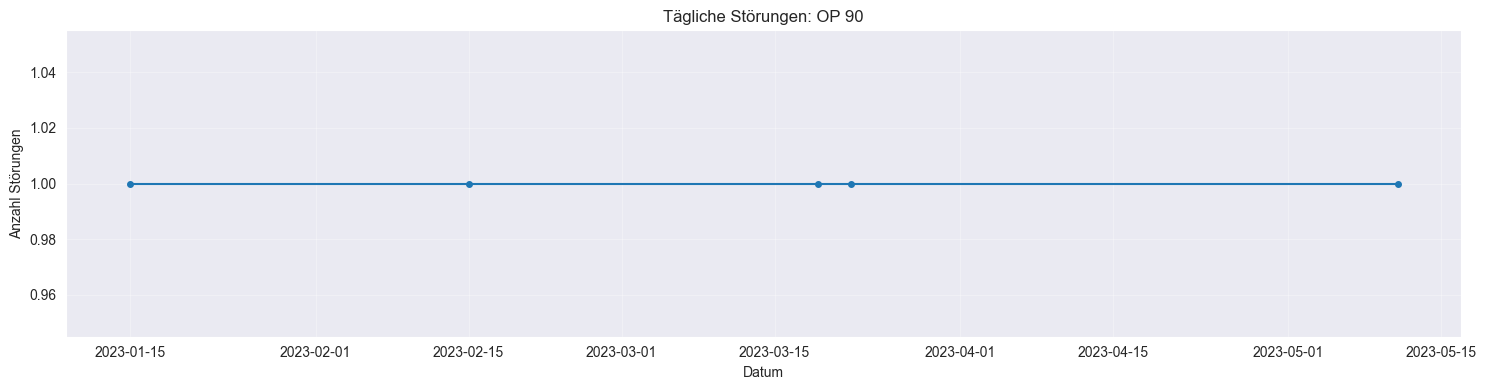

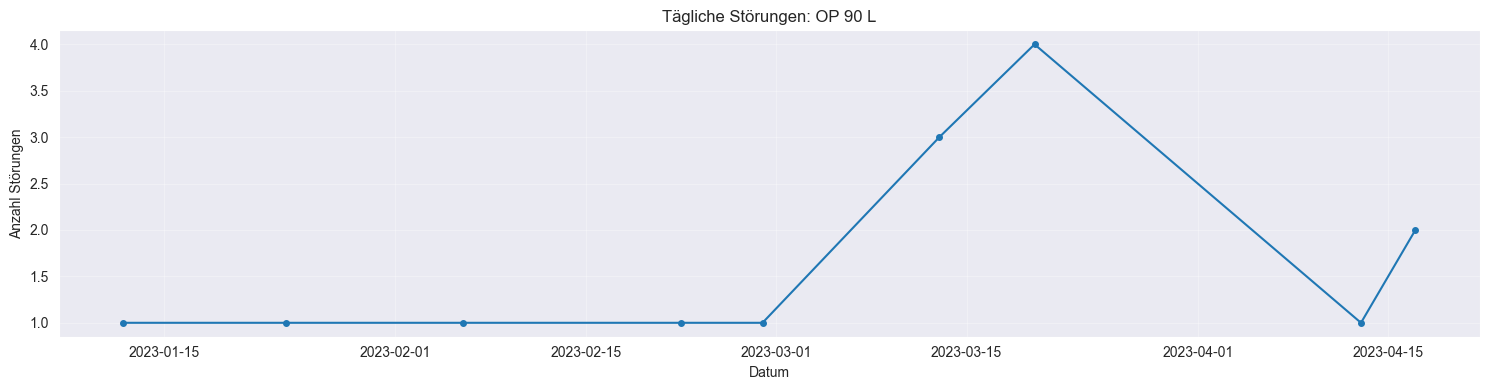

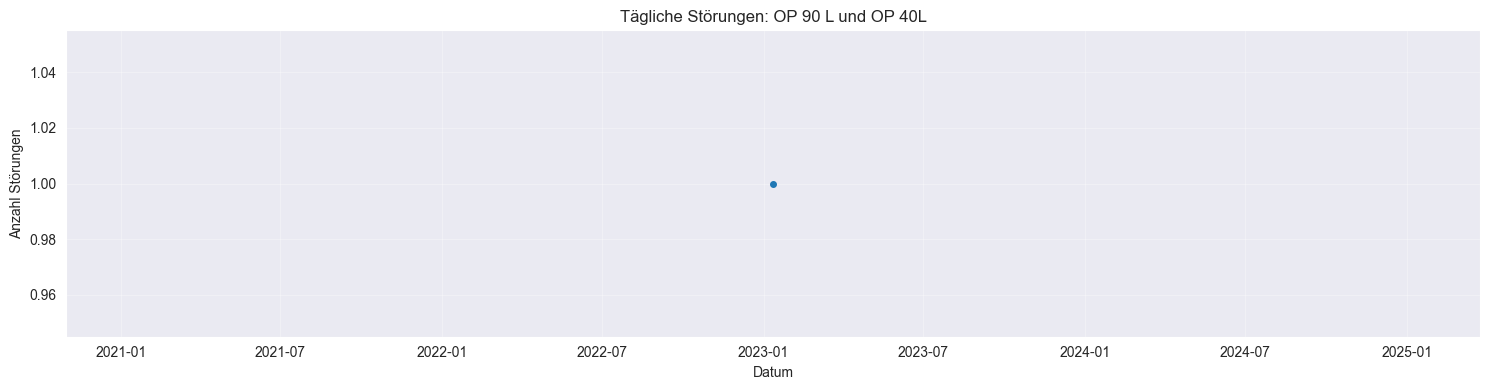

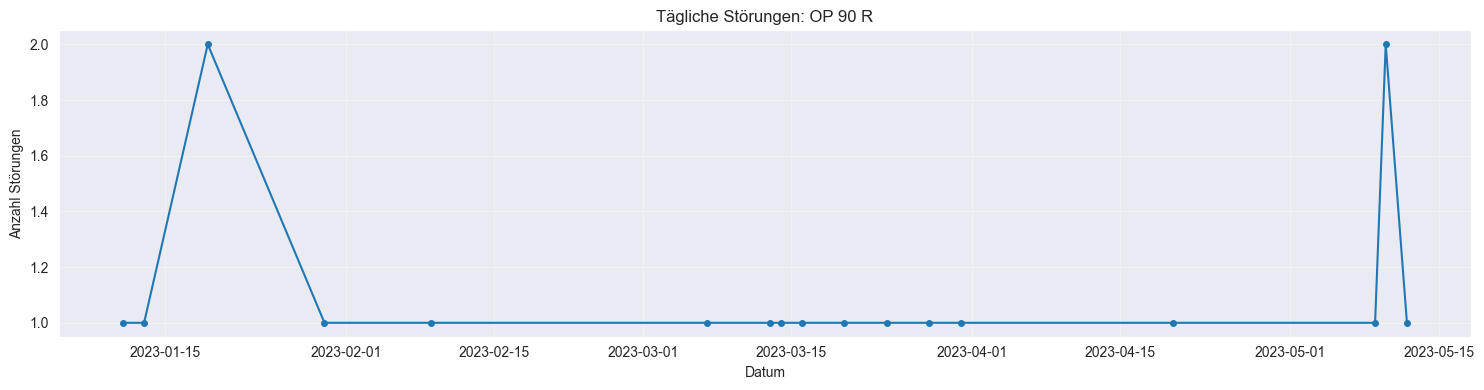

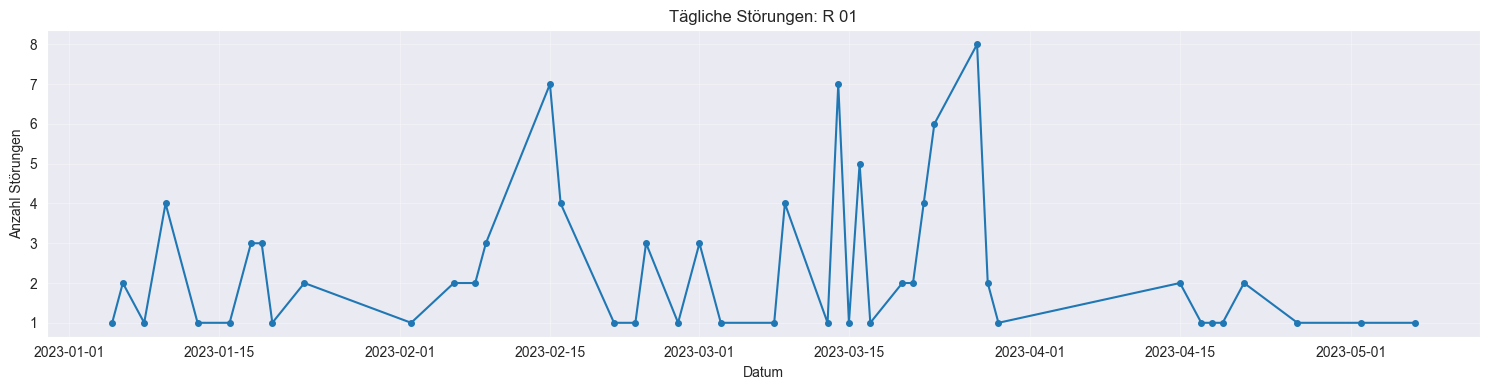

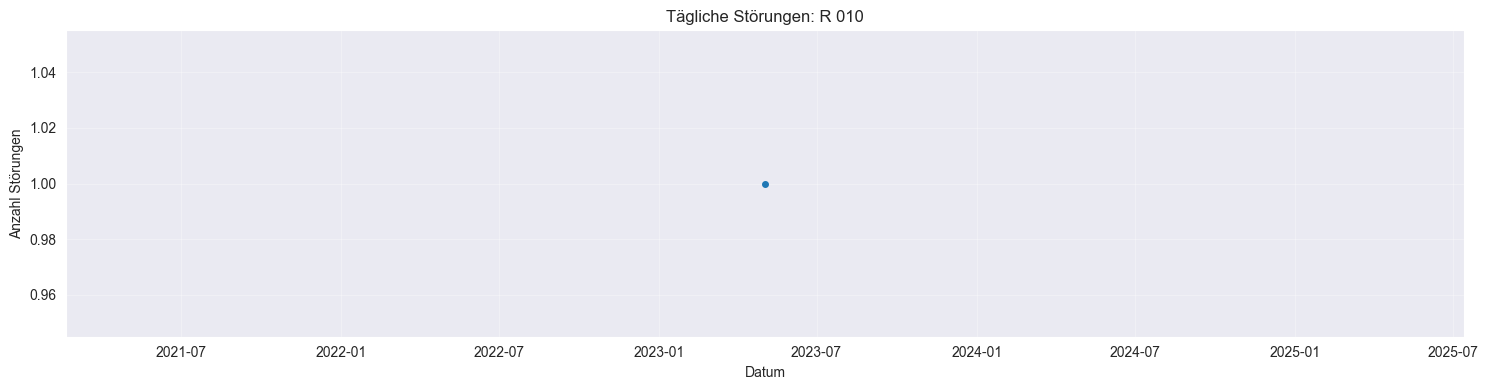

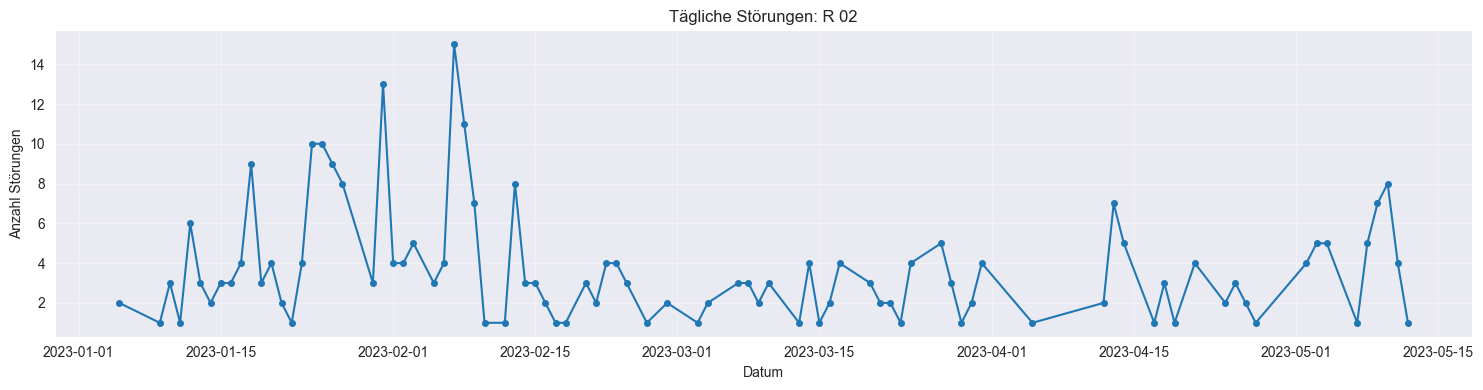

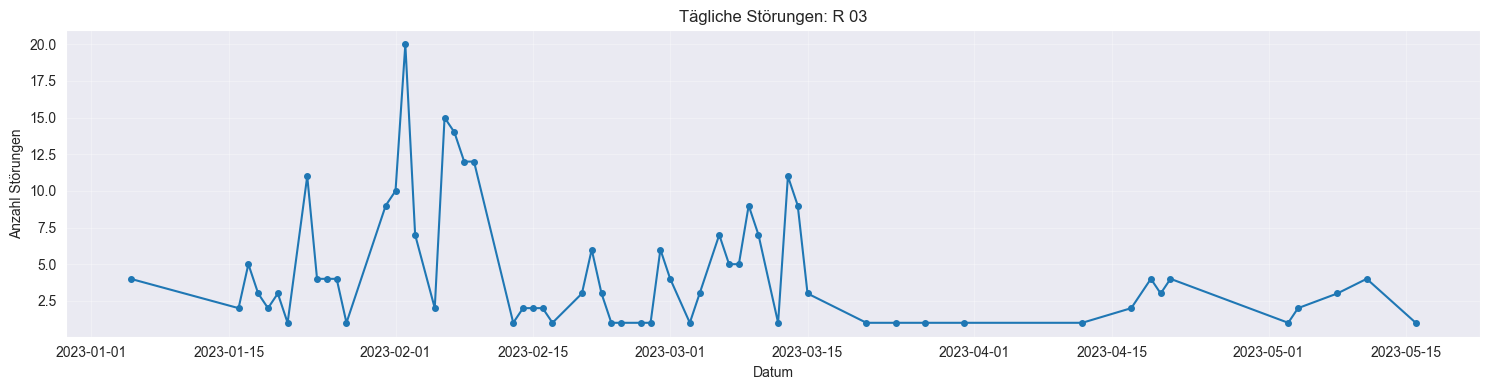

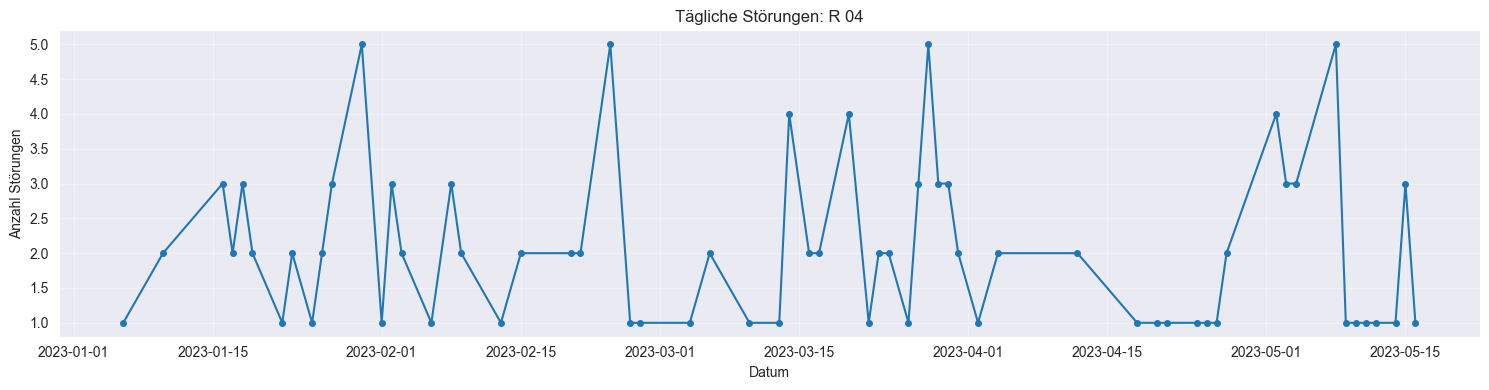

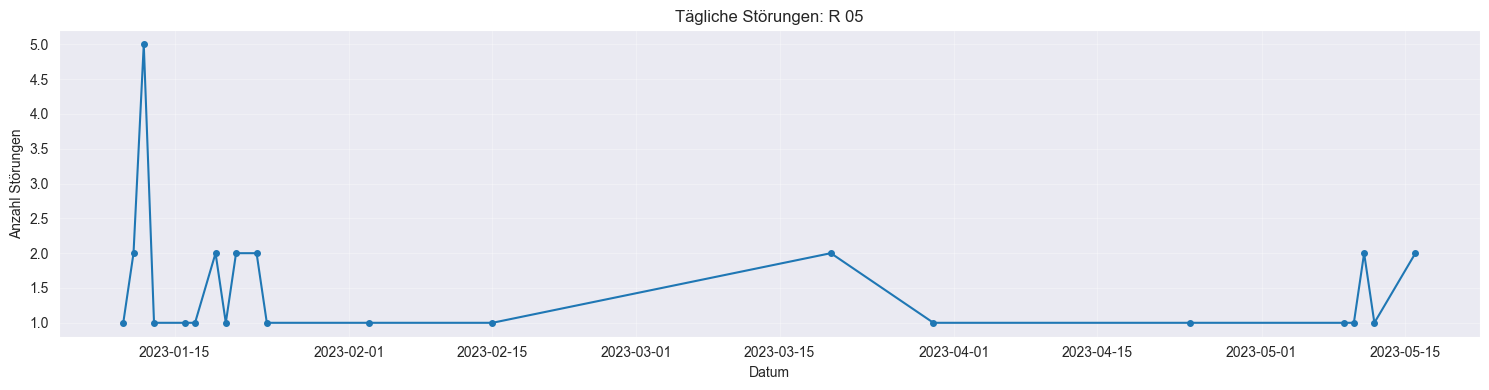

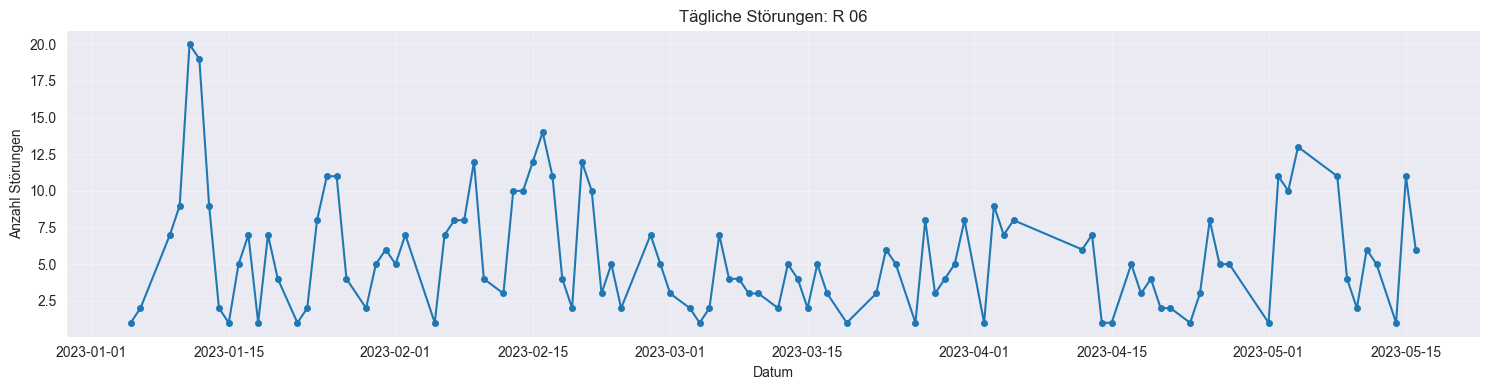

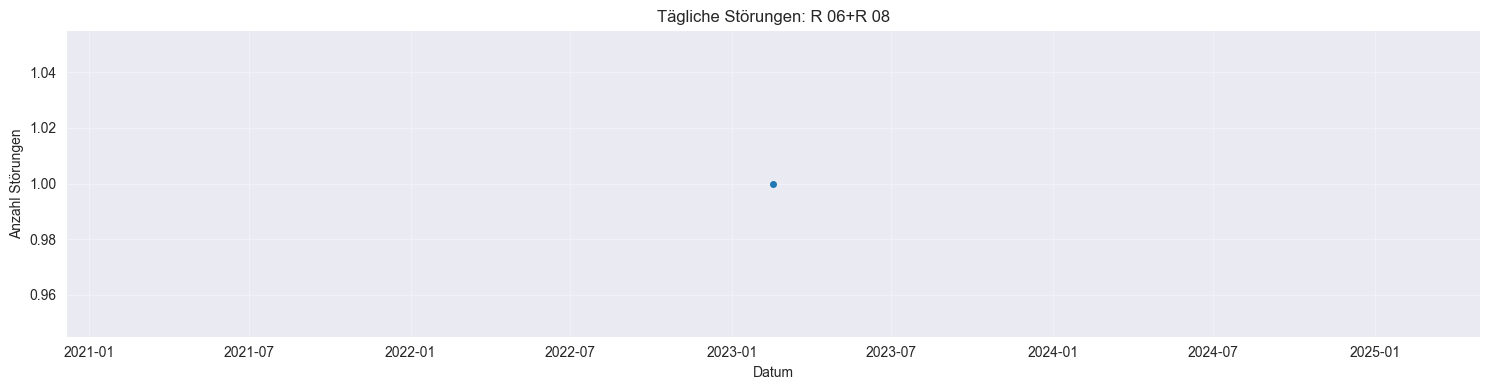

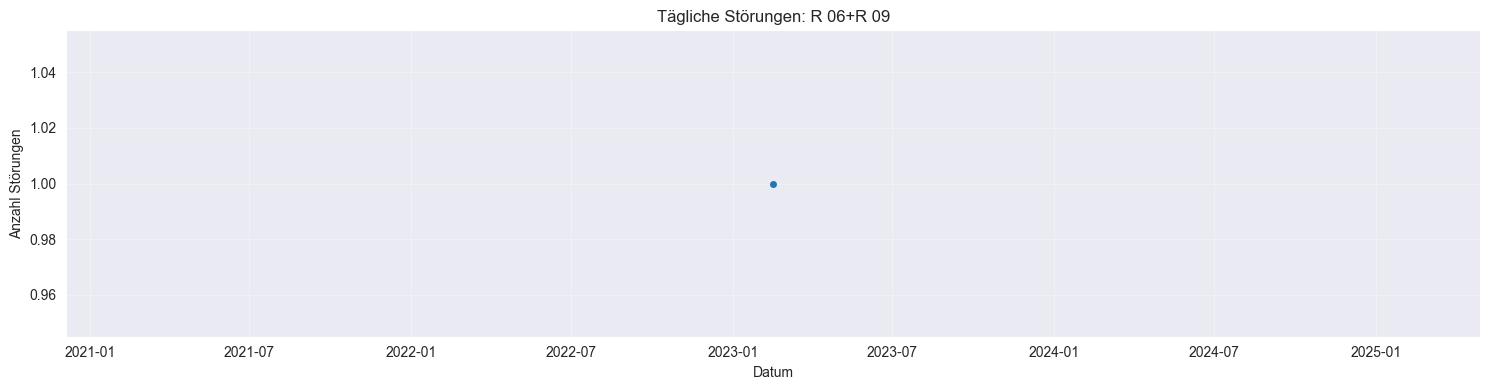

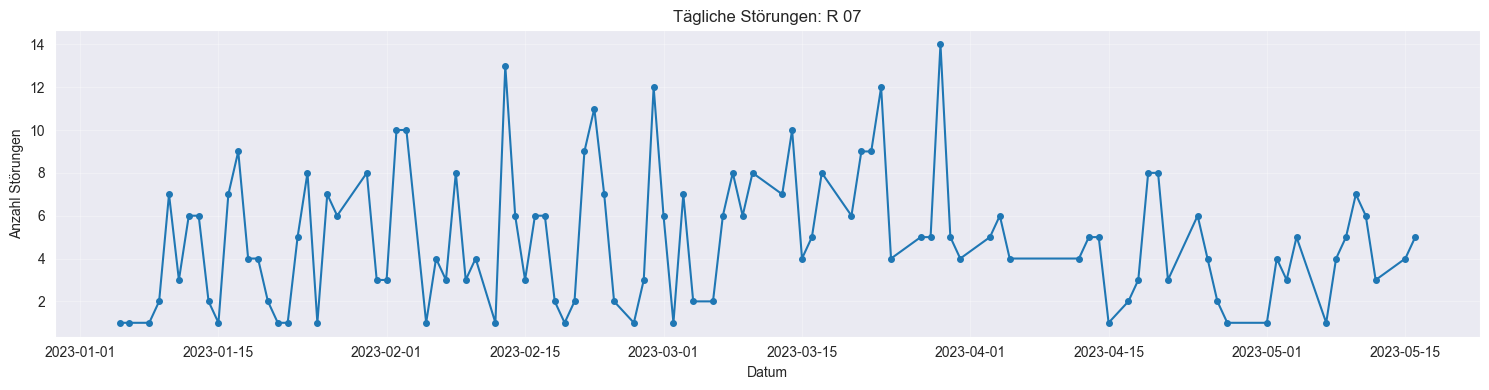

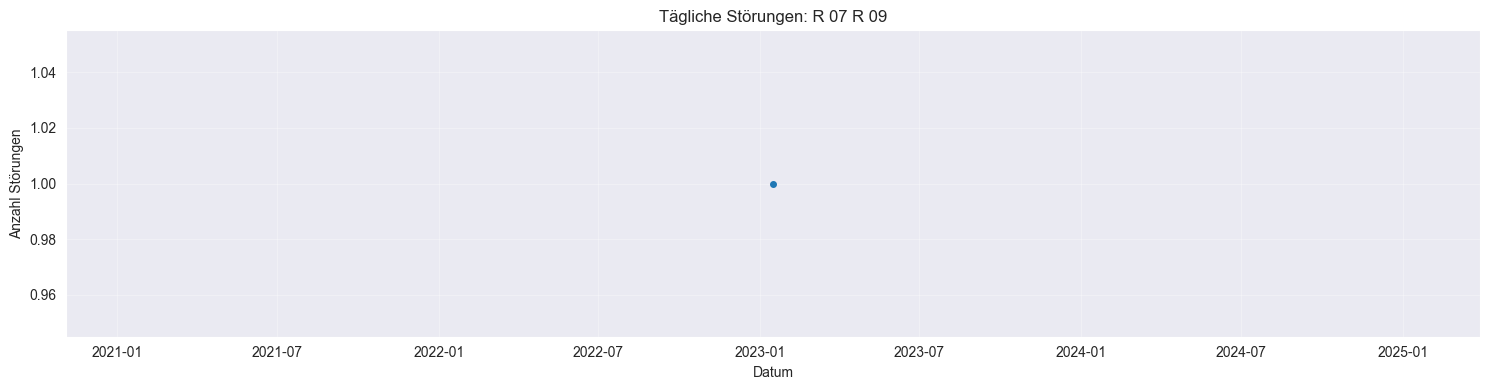

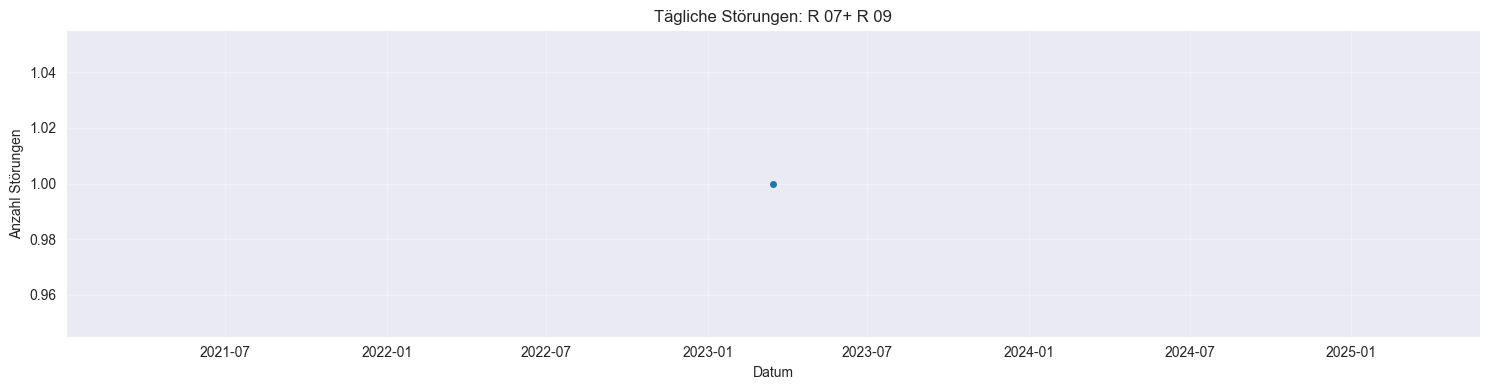

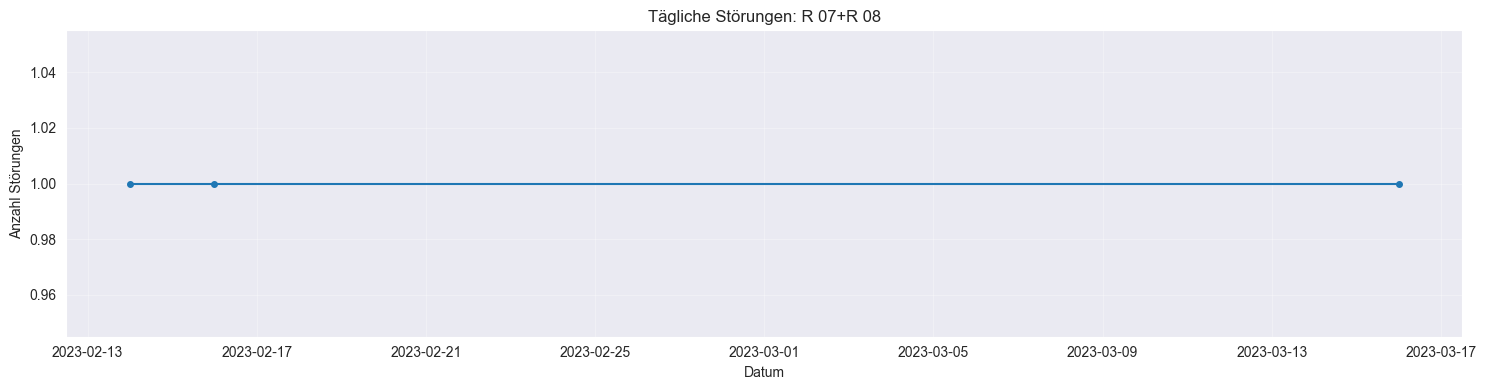

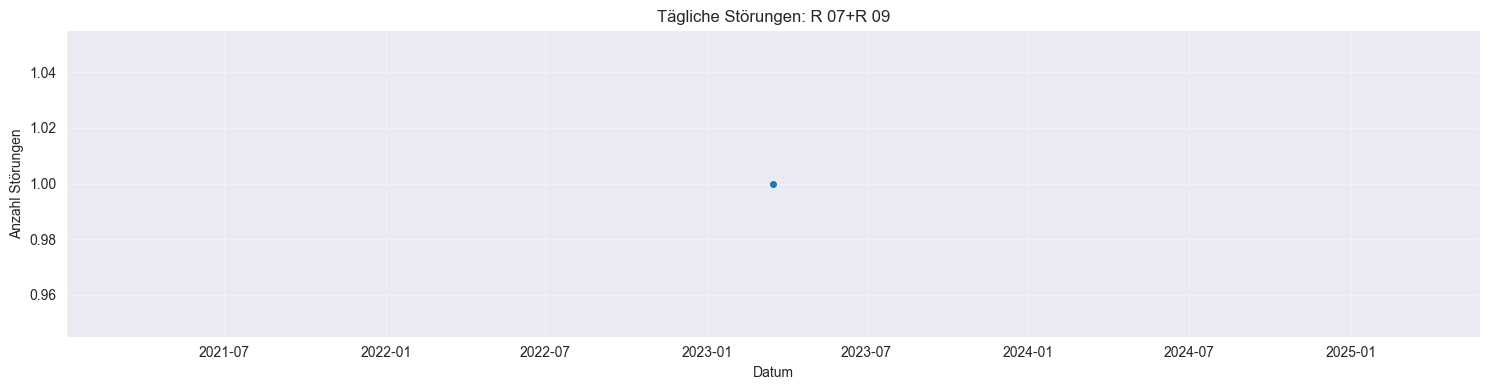

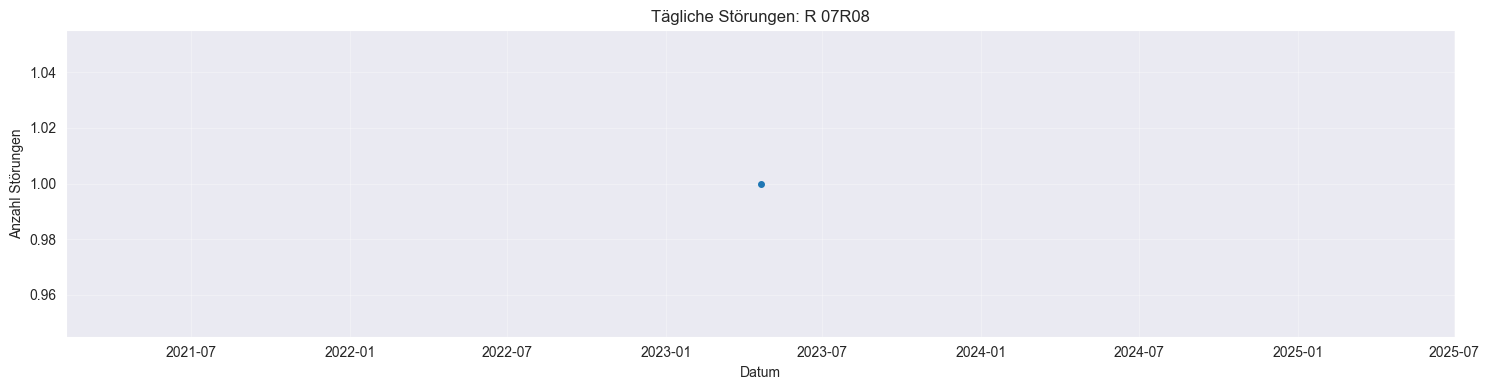

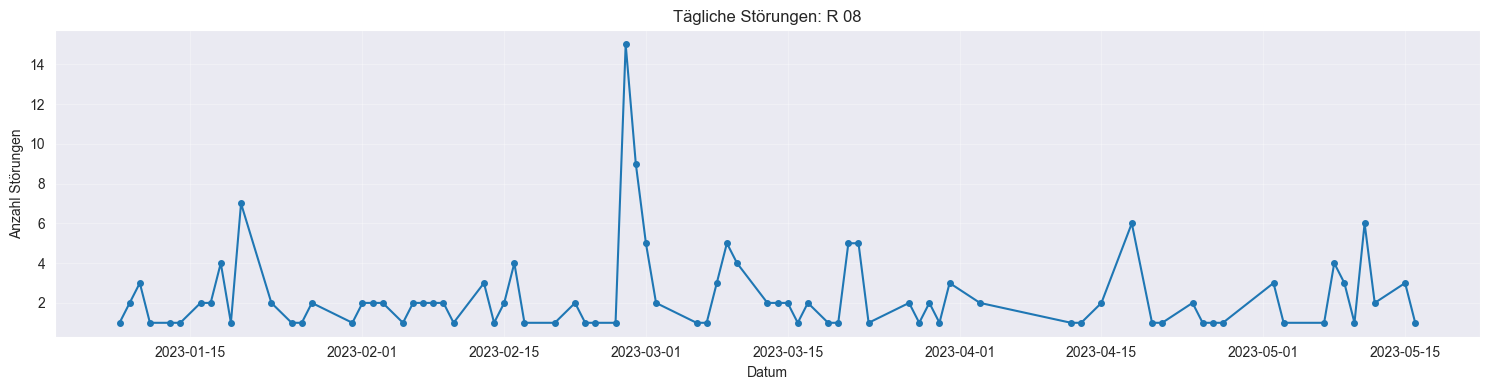

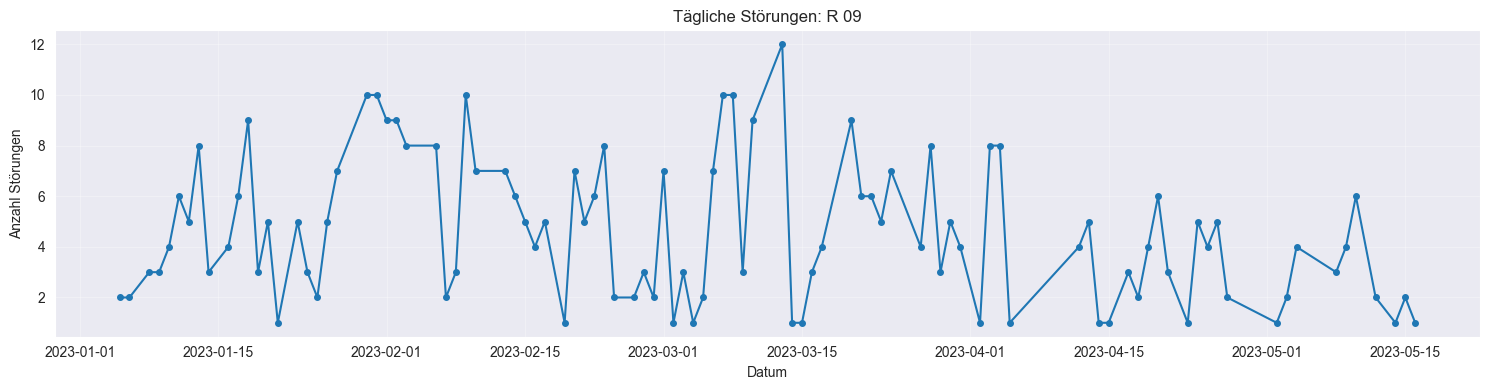

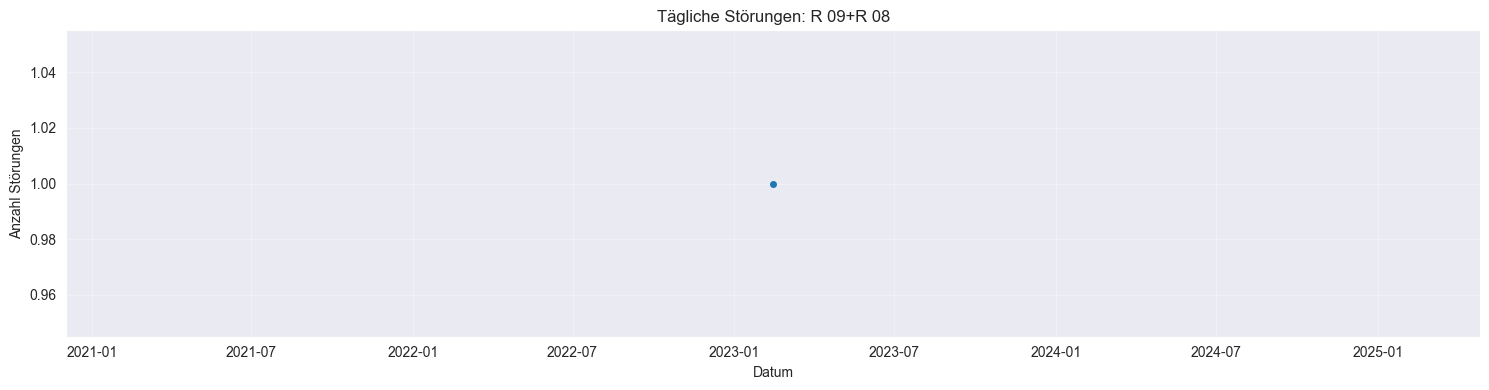

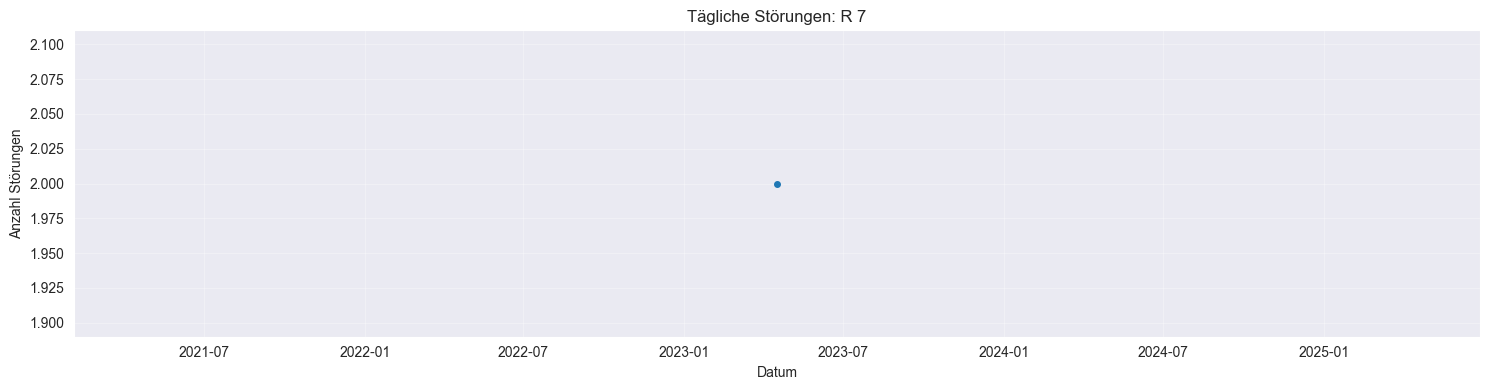

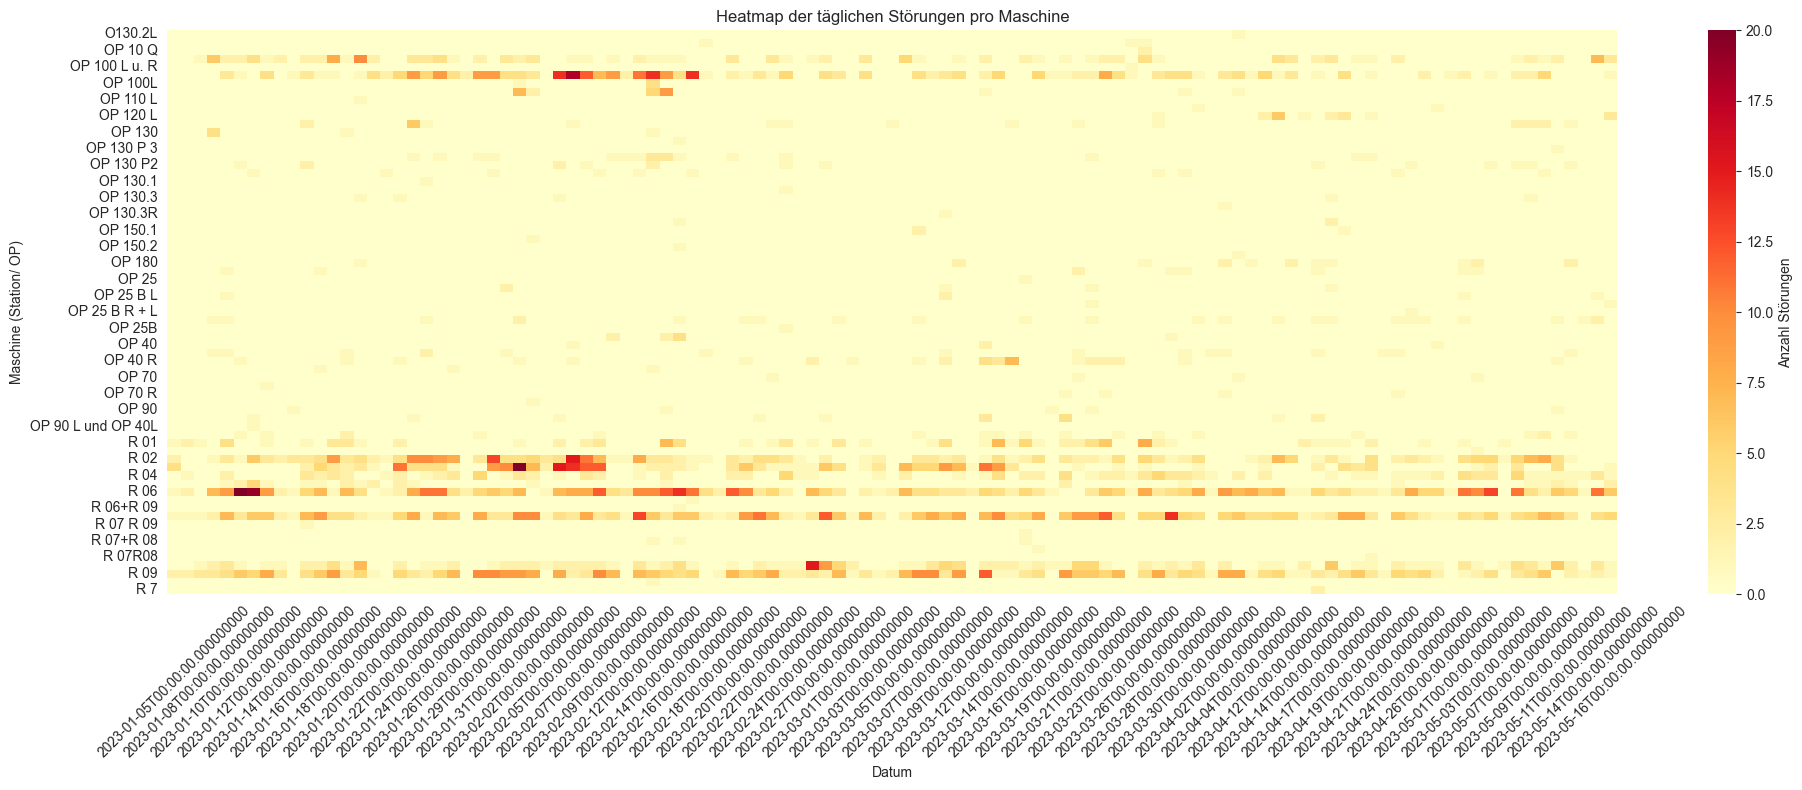

In [3]:


# 2. Vorbereitung: Datum konvertieren
df['Datum'] = pd.to_datetime(df['Datum'])

# Wir definieren eine "Störung" hier als Zeile, in der ein Anlagen-Ausfall 
# oder ein Org-Mangel dokumentiert wurde (Dauer > 0)
# Falls du eine andere Spalte als Indikator bevorzugst, passe dies hier an:
df['hat_stoerung'] = (
    (df['Dauer Anlagen-Ausfall'].fillna(0) > 0) | 
    (df['Dauer Anlagen-Ausfall intern'].fillna(0) > 0)
).astype(int)

# Gruppierung nach Maschine (Station/ OP) und Datum
# Wir zählen die Anzahl der Einträge mit Störungen
daily_faults = df[df['hat_stoerung'] == 1].groupby(['Station/ OP', 'Datum']).size().reset_index(name='Anzahl_Störungen')

# --- VISUALISIERUNG 1: Liniendiagramme pro Maschine ---

machines = daily_faults['Station/ OP'].unique()

for machine in machines:
    machine_data = daily_faults[daily_faults['Station/ OP'] == machine]
    
    plt.figure(figsize=(15, 4))
    plt.plot(machine_data['Datum'], machine_data['Anzahl_Störungen'], marker='o', linestyle='-', markersize=4)
    plt.title(f'Tägliche Störungen: {machine}')
    plt.xlabel('Datum')
    plt.ylabel('Anzahl Störungen')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- VISUALISIERUNG 2: Heatmap ---

# Daten für Heatmap umformen (Pivot-Tabelle)
# Zeilen: Maschinen, Spalten: Datum
heatmap_data = daily_faults.pivot(index='Station/ OP', columns='Datum', values='Anzahl_Störungen').fillna(0)

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Anzahl Störungen'})
plt.title('Heatmap der täglichen Störungen pro Maschine')
plt.xlabel('Datum')
plt.ylabel('Maschine (Station/ OP)')
# Datumsformatierung auf der X-Achse (optional für bessere Lesbarkeit)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()